In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import TensorDataset, DataLoader
import gpytorch
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.data_loader import load_cmapss_data
from src.utils.metrics import phm_scoring_function
from src.models.train_dkl_svgp import train_dkl_autoencoder

# graphic settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
''' 
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from src.data.data_loader import StreamingCMAPSSDataset, get_sensor_feature_columns
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

def compare_cmapss_dataset(dataset_name, dkl_epochs=30):
    print(f"\n\n{'='*60}")
    print(f"🚀 INIZIO VALUTAZIONE DATASET: {dataset_name}")
    print(f"{'='*60}")

    # 1. Load data
    df_train = load_cmapss_data(str(DATA_DIR / f'train_{dataset_name}.txt'), max_rul=125, smooth_targets=False)
    df_test = load_cmapss_data(str(DATA_DIR / f'test_{dataset_name}.txt'), str(DATA_DIR / f'RUL_{dataset_name}.txt'), max_rul=125, smooth_targets=False)

    # 2. Feature Selection
    candidate_cols = ['setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    variances = df_train[candidate_cols].var()
    dead_cols = variances[variances == 0.0].index.tolist()
    features = [c for c in candidate_cols if c not in dead_cols]
    
    print(f"Excluded columns (Zero Variance): {dead_cols if dead_cols else 'None'}")
    print(f"Active features (Settings + Sensors): {len(features)}")

    # 3. Initialize Scalers and Streaming Datasets
    feature_scaler = StandardScaler()
    time_scaler = MinMaxScaler()

    train_dataset = StreamingCMAPSSDataset(
        df=df_train,
        features=features,
        scaler=feature_scaler,
        fit_scaler=True,
        time_scaler=time_scaler,
        fit_time_scaler=True,
        fit_target_transform=True,
        max_rul=125.0
    )
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)

    test_dataset = StreamingCMAPSSDataset(
        df=df_test,
        features=features,
        scaler=feature_scaler,
        fit_scaler=False,
        time_scaler=time_scaler,
        fit_time_scaler=False,
        target_transform=train_dataset.target_transform,
        fit_target_transform=False,
        max_rul=125.0
    )

    X_train_scaled = train_dataset.X.numpy()
    y_train = train_dataset.y_raw.numpy().flatten()
    X_test_scaled = test_dataset.X.numpy()
    y_test_true = test_dataset.y_raw.numpy().flatten()
    
    # 4. Aggiunta coerenza temporale anche per la baseline (Random Forest)
    t_train = train_dataset.time_cycles.numpy().reshape(-1, 1)
    t_test = test_dataset.time_cycles.numpy().reshape(-1, 1)
    
    X_train_scaled_rf = np.hstack([X_train_scaled, t_train])
    X_test_scaled_rf = np.hstack([X_test_scaled, t_test])

    last_cycle_indices = df_test.groupby('unit_nr').tail(1).index
    X_test_last_rf = X_test_scaled_rf[last_cycle_indices]
    y_test_last = y_test_true[last_cycle_indices]

    # --- RANDOM FOREST ---
    print("🌲 Training Baseline (Random Forest) con feature temporale...")
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_model.fit(X_train_scaled_rf, y_train)

    rf_preds_last = rf_model.predict(X_test_last_rf)
    
    rf_rmse = np.sqrt(mean_squared_error(y_test_last, rf_preds_last))
    rf_mae = mean_absolute_error(y_test_last, rf_preds_last)
    rf_r2 = r2_score(y_test_last, rf_preds_last)
    rf_score = phm_scoring_function(rf_preds_last, y_test_last)
    
    rf_errors = rf_preds_last - y_test_last
    rf_late_count = np.sum(rf_errors > 0)
    rf_early_count = np.sum(rf_errors < 0)

    rf_preds_all = rf_model.predict(X_test_scaled_rf)

    # --- DKL + SVGP ---
    print(f"🧠 Training Proposed Model (DKL+SVGP - {dkl_epochs} epoche)...")
    dkl_model, likelihood = train_dkl_autoencoder(
        train_loader=train_loader,
        input_dim=len(features),
        latent_dim=16,
        num_inducing=500,
        epochs=dkl_epochs,
        encoder_lr=1e-4,
        decoder_lr=1e-4,
        gp_lr=5e-4,
        lambda_recon=0.5,
        lambda_asymm=0.5,
        lambda_interval=1.0,
        interval_alpha=0.05,
        interval_alpha_lo_scale=0.2,
        beta_kl=0.5,
        grad_clip=1.0,
        seed=42
    )

    dkl_model.to(device)
    likelihood.to(device)
    dkl_model.eval()
    likelihood.eval()

    X_test_last = X_test_scaled[last_cycle_indices]
    X_test_last_tensor = torch.tensor(X_test_last, dtype=torch.float32).to(device)
    t_test_last_tensor = test_dataset.time_cycles[last_cycle_indices].to(device)

    X_test_all_tensor = test_dataset.X.to(device)
    t_test_all_tensor = test_dataset.time_cycles.to(device)

    with torch.no_grad():
        prediction_last = dkl_model.predict_with_uncertainty(
            X_test_last_tensor, normalized_cycle=t_test_last_tensor, likelihood=likelihood
        )
        dkl_preds_last = prediction_last['mean'].cpu().numpy()
        dkl_preds_last = train_dataset.inverse_transform(dkl_preds_last)
        
        dkl_rmse = np.sqrt(mean_squared_error(y_test_last, dkl_preds_last))
        dkl_mae = mean_absolute_error(y_test_last, dkl_preds_last)
        dkl_r2 = r2_score(y_test_last, dkl_preds_last)
        dkl_score = phm_scoring_function(dkl_preds_last, y_test_last)

        dkl_errors = dkl_preds_last - y_test_last
        dkl_late_count = np.sum(dkl_errors > 0)
        dkl_early_count = np.sum(dkl_errors < 0)

        prediction_all = dkl_model.predict_with_uncertainty(
            X_test_all_tensor, normalized_cycle=t_test_all_tensor, likelihood=likelihood
        )
        dkl_preds_all = prediction_all['mean'].cpu().numpy()
        dkl_lower_all = prediction_all['lower'].cpu().numpy()
        dkl_upper_all = prediction_all['upper'].cpu().numpy()

        dkl_preds_all = train_dataset.inverse_transform(dkl_preds_all)
        dkl_lower_all = train_dataset.inverse_transform(dkl_lower_all)
        dkl_upper_all = train_dataset.inverse_transform(dkl_upper_all)

    print("\n📊 --- REPORT METRICHE FINALI ---")
    print(f"{'Metrica':<20} | {'Random Forest':<15} | {'DKL+SVGP':<15}")
    print("-" * 55)
    print(f"{'RMSE (Cicli)':<20} | {rf_rmse:<15.2f} | {dkl_rmse:<15.2f}")
    print(f"{'MAE (Cicli)':<20} | {rf_mae:<15.2f} | {dkl_mae:<15.2f}")
    print(f"{'R-Squared (R2)':<20} | {rf_r2:<15.3f} | {dkl_r2:<15.3f}")
    print(f"{'C-MAPSS Score':<20} | {rf_score:<15.0f} | {dkl_score:<15.0f}")
    print(f"{'Late Preds (Guasti)':<20} | {rf_late_count:<15} | {dkl_late_count:<15}")
    print(f"{'Early Preds (Sicuri)':<20} | {rf_early_count:<15} | {dkl_early_count:<15}")
    print("-" * 55)

    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.5])

    ax_rmse = fig.add_subplot(gs[0, 0])
    ax_score = fig.add_subplot(gs[0, 1])
    ax_traj = fig.add_subplot(gs[1, :]) 

    models_labels = ['Baseline\n(Random Forest)', 'Proposed\n(DKL + SVGP)']
    palette = ['#8c564b', '#1f77b4']

    sns.barplot(x=models_labels, y=[rf_rmse, dkl_rmse], ax=ax_rmse, palette=palette)
    ax_rmse.set_title(f'[{dataset_name}] RMSE on Final Cycle', fontsize=14, fontweight='bold')
    ax_rmse.set_ylabel('RMSE (Cycles)')
    for i, v in enumerate([rf_rmse, dkl_rmse]):
        ax_rmse.text(i, v + (max(rf_rmse, dkl_rmse)*0.02), f"{v:.2f}", ha='center', fontsize=12)

    sns.barplot(x=models_labels, y=[rf_score, dkl_score], ax=ax_score, palette=palette)
    ax_score.set_title(f'[{dataset_name}] C-MAPSS Score on Final Cycle', fontsize=14, fontweight='bold')
    ax_score.set_ylabel('Penalty Score')
    for i, v in enumerate([rf_score, dkl_score]):
        ax_score.text(i, v + (max(rf_score, dkl_score)*0.02), f"{v:,.0f}", ha='center', fontsize=12)

    first_engine_id = df_test['unit_nr'].unique()[0]
    eng_indices = df_test[df_test['unit_nr'] == first_engine_id].index
    y_true_eng = y_test_true[eng_indices]
    cycles = range(len(y_true_eng))

    ax_traj.plot(cycles, y_true_eng, label='True RUL', color='black', linewidth=3)
    ax_traj.plot(cycles, rf_preds_all[eng_indices], label='Random Forest Mean', color='#8c564b', linestyle='-.', linewidth=2.5)
    ax_traj.plot(cycles, dkl_preds_all[eng_indices], label='DKL+SVGP Mean', color='#1f77b4', linestyle='--', linewidth=2.5)
    ax_traj.fill_between(cycles, dkl_lower_all[eng_indices], dkl_upper_all[eng_indices], color='#1f77b4', alpha=0.2, label='DKL+SVGP (95% CI)')

    ax_traj.set_title(f'[{dataset_name}] Prediction Trajectories - Test Engine #{first_engine_id}', fontsize=16, fontweight='bold', pad=15)
    ax_traj.set_xlabel('Operational Cycle', fontsize=12)
    ax_traj.set_ylabel('Remaining Useful Life (RUL)', fontsize=12)
    ax_traj.legend(fontsize=12, loc='upper right')
    ax_traj.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {'rf_rmse': rf_rmse, 'dkl_rmse': dkl_rmse, 'rf_score': rf_score, 'dkl_score': dkl_score}
    '''

' \nfrom sklearn.metrics import mean_absolute_error, r2_score\nfrom sklearn.preprocessing import MinMaxScaler\nfrom src.data.data_loader import StreamingCMAPSSDataset, get_sensor_feature_columns\nDATA_DIR = PROJECT_ROOT / \'data\' / \'raw\'\n\ndef compare_cmapss_dataset(dataset_name, dkl_epochs=30):\n    print(f"\n\n{\'=\'*60}")\n    print(f"🚀 INIZIO VALUTAZIONE DATASET: {dataset_name}")\n    print(f"{\'=\'*60}")\n\n    # 1. Load data\n    df_train = load_cmapss_data(str(DATA_DIR / f\'train_{dataset_name}.txt\'), max_rul=125, smooth_targets=False)\n    df_test = load_cmapss_data(str(DATA_DIR / f\'test_{dataset_name}.txt\'), str(DATA_DIR / f\'RUL_{dataset_name}.txt\'), max_rul=125, smooth_targets=False)\n\n    # 2. Feature Selection\n    candidate_cols = [\'setting_1\', \'setting_2\', \'setting_3\'] + [f\'s_{i}\' for i in range(1, 22)]\n    variances = df_train[candidate_cols].var()\n    dead_cols = variances[variances == 0.0].index.tolist()\n    features = [c for c in candidate_cols if

In [3]:
'''
global_results = {}

# Test FD001
global_results['FD001'] = compare_cmapss_dataset('FD001', dkl_epochs=100)

# Test FD002
#global_results['FD002'] = compare_cmapss_dataset('FD002', dkl_epochs=100)

# Test FD003
#global_results['FD003'] = compare_cmapss_dataset('FD003', dkl_epochs=100)

# Test FD004
#global_results['FD004'] = compare_cmapss_dataset('FD004', dkl_epochs=100)


print("\n=== RIEPILOGO FINALE METRICHE ===")
for ds, metrics in global_results.items():
    print(f"{ds} -> RF RMSE: {metrics['rf_rmse']:.2f} | DKL RMSE: {metrics['dkl_rmse']:.2f}")
    '''

'\nglobal_results = {}\n\n# Test FD001\nglobal_results[\'FD001\'] = compare_cmapss_dataset(\'FD001\', dkl_epochs=100)\n\n# Test FD002\n#global_results[\'FD002\'] = compare_cmapss_dataset(\'FD002\', dkl_epochs=100)\n\n# Test FD003\n#global_results[\'FD003\'] = compare_cmapss_dataset(\'FD003\', dkl_epochs=100)\n\n# Test FD004\n#global_results[\'FD004\'] = compare_cmapss_dataset(\'FD004\', dkl_epochs=100)\n\n\nprint("\n=== RIEPILOGO FINALE METRICHE ===")\nfor ds, metrics in global_results.items():\n    print(f"{ds} -> RF RMSE: {metrics[\'rf_rmse\']:.2f} | DKL RMSE: {metrics[\'dkl_rmse\']:.2f}")\n    '

# BAYESIAN VS DKL

In [4]:
# ==============================================================================
# COMPARE: BAYESIAN RIDGE vs DKL + SVGP
# ==============================================================================
import os
import joblib
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import DataLoader
import gpytorch

from src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset
from src.utils.metrics import (
    evaluate_prognostics_model,
    gaussian_nll_from_mean_var,
    crps_gaussian
)
from src.models.train_dkl_svgp import train_dkl_autoencoder

DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
CHECKPOINTS_DIR = PROJECT_ROOT / 'artifacts' / 'checkpoints'
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# use_saved_model settato a False di default per rigenerare i modelli con il tempo integrato
def compare_br_vs_dkl_dataset(dataset_name, dkl_epochs=100, use_saved_model=False):
    print(f"\n\n{'='*90}")
    print(f"🔬 INIZIO VALUTAZIONE PROBABILISTICA COMPLETA: BR vs DKL+SVGP [{dataset_name}]")
    print(f"{'='*90}")

    br_model_path = CHECKPOINTS_DIR / f'br_model_{dataset_name}.pkl'
    dkl_model_path = CHECKPOINTS_DIR / f'dkl_model_{dataset_name}.pth'
    likelihood_path = CHECKPOINTS_DIR / f'likelihood_{dataset_name}.pth'

    # 1. Load data
    df_train = load_cmapss_data(str(DATA_DIR / f'train_{dataset_name}.txt'), max_rul=125, smooth_targets=False)
    df_test = load_cmapss_data(str(DATA_DIR / f'test_{dataset_name}.txt'), str(DATA_DIR / f'RUL_{dataset_name}.txt'), max_rul=125, smooth_targets=False)

    # 2. Feature Selection
    candidate_cols = ['setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    variances = df_train[candidate_cols].var()
    dead_cols = variances[variances == 0.0].index.tolist()
    features = [c for c in candidate_cols if c not in dead_cols]

    # 3. Inizializzazione Scaler
    # feature_scaler = StandardScaler()
    # time_scaler = MinMaxScaler()

    # ==========================================================
    # 3. Inizializzazione Scaler (MODIFICATO)
    # ==========================================================
    from src.data.data_loader import RegimeConditionedScaler
    
    if dataset_name in ['FD002', 'FD004']:
        print("🌍 Dataset multi-regime rilevato: Applicazione RegimeConditionedScaler (6 cluster)...")
        feature_scaler = RegimeConditionedScaler(n_regimes=6, setting_cols_indices=(0, 1, 2))
    else:
        print("✈️ Dataset mono-regime rilevato: Applicazione StandardScaler globale...")
        feature_scaler = StandardScaler()
        
    time_scaler = MinMaxScaler()
    # ==========================================================




    # Creazione del Dataset di Train con estrazione del Tempo
    train_dataset = StreamingCMAPSSDataset(
        df=df_train,
        features=features,
        scaler=feature_scaler,
        fit_scaler=True,
        time_scaler=time_scaler,
        fit_time_scaler=True,
        fit_target_transform=True,
        max_rul=125.0
    )
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)

    # Creazione Dataset di Test
    test_dataset = StreamingCMAPSSDataset(
        df=df_test,
        features=features,
        scaler=feature_scaler,
        fit_scaler=False,
        time_scaler=time_scaler,
        fit_time_scaler=False,
        target_transform=train_dataset.target_transform,
        fit_target_transform=False,
        max_rul=125.0
    )

    X_train_scaled = train_dataset.X.numpy()
    y_train = train_dataset.y_raw.numpy().flatten()
    X_test_scaled = test_dataset.X.numpy()
    y_test_true = test_dataset.y_raw.numpy().flatten()

    # 4. Integrazione coerente del tempo per Bayesian Ridge
    t_train = train_dataset.time_cycles.numpy().reshape(-1, 1)
    t_test = test_dataset.time_cycles.numpy().reshape(-1, 1)
    
    X_train_scaled_br = np.hstack([X_train_scaled, t_train])
    X_test_scaled_br = np.hstack([X_test_scaled, t_test])

    # 5. Extracting Last Cycles
    last_cycle_indices = df_test.groupby('unit_nr').tail(1).index
    X_test_last_br = X_test_scaled_br[last_cycle_indices]
    y_test_last = y_test_true[last_cycle_indices]
    unit_nrs_last = df_test.iloc[last_cycle_indices]['unit_nr'].values

    # ==========================================
    # --- BAYESIAN RIDGE ---
    # ==========================================
    if use_saved_model and br_model_path.exists():
        print(f"Loading Baseline (Bayesian Ridge) from disk for {dataset_name}...")
        br_model = joblib.load(br_model_path)
    else:
        print("Training Baseline (Bayesian Ridge) con feature temporale integrata...")
        br_model = BayesianRidge()
        br_model.fit(X_train_scaled_br, y_train)
        joblib.dump(br_model, br_model_path)
        print(f"Bayesian Ridge salvata in {br_model_path.name}")

    # Probabilistic predictive params (last cycle)
    br_preds_last, br_std_last = br_model.predict(X_test_last_br, return_std=True)
    br_var_last = br_std_last ** 2
    br_lower_last = br_preds_last - (1.96 * br_std_last)
    br_upper_last = br_preds_last + (1.96 * br_std_last)
    
    # Metrics evaluation
    br_metrics = evaluate_prognostics_model(
        br_preds_last, y_test_last, 
        predictive_vars=br_var_last, lower_bounds=br_lower_last, upper_bounds=br_upper_last
    )
    br_nll = gaussian_nll_from_mean_var(br_preds_last, br_var_last, y_test_last)
    br_crps = crps_gaussian(br_preds_last, br_var_last, y_test_last)

    # Trajectory predictions (all cycles)
    br_preds_all, br_std_all = br_model.predict(X_test_scaled_br, return_std=True)
    br_lower_all = br_preds_all - (1.96 * br_std_all)
    br_upper_all = br_preds_all + (1.96 * br_std_all)

    dimensioni_latenti = 8
    if dataset_name == "FD002":
        dimensioni_latenti = 20

    if dataset_name == "FD004":
        dimensioni_latenti = 16

    # ==========================================
    # --- DKL + SVGP ---
    # ==========================================
    if use_saved_model and dkl_model_path.exists() and likelihood_path.exists():
        print(f"🔄 Caricamento Modello Proposto (DKL+SVGP) da disco per {dataset_name}...")
        dkl_model = torch.load(dkl_model_path, weights_only=False, map_location=device)
        likelihood = torch.load(likelihood_path, weights_only=False, map_location=device)
    else:
        print(f"Training Proposed Model (DKL+SVGP - {dkl_epochs} epoche)...")
        dkl_model, likelihood = train_dkl_autoencoder(
            train_loader=train_loader,
            input_dim=len(features),
            latent_dim=16,                # Manteniamo 16 per la grandezza di FD002
            num_inducing=700,
            epochs=dkl_epochs,
            encoder_lr=1e-4,
            decoder_lr=1e-4,
            gp_lr=5e-4,
            # --- RITORNO ALLO SWEET SPOT (Assetto FD001) ---
            lambda_recon=0.5,             # Normale ricostruzione strutturale
            lambda_asymm=0.5,             # DIMEZZATO: basta forzare le stime sotto lo zero!
            lambda_interval=2.0,          # Leggera pressione per mantenere le bande compatte
            interval_alpha=0.05,          # Allineato al 95%
            interval_alpha_lo_scale=0.25, # Bias conservativo standard
            beta_kl=0.5,                  # Regolarizzazione Bayesiana bilanciata

            grad_clip=1.0,
            seed=42
        )
        
        torch.save(dkl_model, dkl_model_path)
        torch.save(likelihood, likelihood_path)
        print(f"Modello DKL+SVGP salvato in {dkl_model_path.name}")

    dkl_model.to(device)
    likelihood.to(device)
    dkl_model.eval()
    likelihood.eval()

    X_test_last = X_test_scaled[last_cycle_indices]
    X_test_last_tensor = torch.tensor(X_test_last, dtype=torch.float32).to(device)
    t_test_last_tensor = test_dataset.time_cycles[last_cycle_indices].to(device)

    X_test_all_tensor = test_dataset.X.to(device)
    t_test_all_tensor = test_dataset.time_cycles.to(device)

    with torch.no_grad():
        # Last cycle predictions con TEMPO aggiunto
        prediction_last = dkl_model.predict_with_uncertainty(
            X_test_last_tensor, normalized_cycle=t_test_last_tensor, likelihood=likelihood
        )
        dkl_preds_last = prediction_last['mean'].cpu().numpy()
        dkl_var_last = prediction_last['variance'].cpu().numpy()
        dkl_lower_last = prediction_last['lower'].cpu().numpy()
        dkl_upper_last = prediction_last['upper'].cpu().numpy()

        dkl_preds_last, dkl_var_last = train_dataset.inverse_transform(dkl_preds_last, variance=dkl_var_last)
        dkl_lower_last = train_dataset.inverse_transform(dkl_lower_last)
        dkl_upper_last = train_dataset.inverse_transform(dkl_upper_last)

        # Metrics evaluation
        dkl_metrics = evaluate_prognostics_model(
            dkl_preds_last, y_test_last, 
            predictive_vars=dkl_var_last, lower_bounds=dkl_lower_last, upper_bounds=dkl_upper_last
        )
        dkl_nll = gaussian_nll_from_mean_var(dkl_preds_last, dkl_var_last, y_test_last)
        dkl_crps = crps_gaussian(dkl_preds_last, dkl_var_last, y_test_last)

        # Trajectory predictions (all cycles) con TEMPO aggiunto
        prediction_all = dkl_model.predict_with_uncertainty(
            X_test_all_tensor, normalized_cycle=t_test_all_tensor, likelihood=likelihood
        )
        dkl_preds_all = prediction_all['mean'].cpu().numpy()
        dkl_lower_all = prediction_all['lower'].cpu().numpy()
        dkl_upper_all = prediction_all['upper'].cpu().numpy()

        dkl_preds_all = train_dataset.inverse_transform(dkl_preds_all)
        dkl_lower_all = train_dataset.inverse_transform(dkl_lower_all)
        dkl_upper_all = train_dataset.inverse_transform(dkl_upper_all)


    print("\n --- STIME PUNTUALI E INTERVALLI DI CONFIDENZA (95%) SUI CICLI FINALI (Prime 5 UUT) ---")
    header = f"{'Unit ID':<8} | {'True RUL':<8} | {'BR Pred':<8} | {'Intervallo Bayesian Ridge':<32} | {'DKL Pred':<8} | {'Intervallo DKL+SVGP':<32}"
    print(header)
    print("-" * len(header))
    for i in range(min(15, len(unit_nrs_last))):
        br_width = br_upper_last[i] - br_lower_last[i]
        dkl_width = dkl_upper_last[i] - dkl_lower_last[i]
        
        br_str = f"[{br_lower_last[i]:.1f}, {br_upper_last[i]:.1f}] (w:{br_width:.1f})"
        dkl_str = f"[{dkl_lower_last[i]:.1f}, {dkl_upper_last[i]:.1f}] (w:{dkl_width:.1f})"
        
        print(f"UUT #{unit_nrs_last[i]:<4} | {y_test_last[i]:<8.0f} | {br_preds_last[i]:<8.1f} | {br_str:<32} | {dkl_preds_last[i]:<8.1f} | {dkl_str:<32}")
    print("-" * len(header))

    br_rmse = br_metrics['RMSE (Root Mean Squared Error)']
    dkl_rmse = dkl_metrics['RMSE (Root Mean Squared Error)']
    br_score_val = br_metrics['PHM08 Asymmetric Score (Lower is better)']
    dkl_score_val = dkl_metrics['PHM08 Asymmetric Score (Lower is better)']

    # ==========================================
    # --- REPORT DI TUTTE LE METRICHE ---
    # ==========================================
    print("\n --- REPORT METRICHE FINALI COMPLETO ---")
    print(f"{'Metrica':<45} | {'Bayesian Ridge':<15} | {'DKL+SVGP':<15}")
    print("-" * 81)
    print(f"{'RMSE (Cicli) [↓]':<45} | {br_rmse:<15.2f} | {dkl_rmse:<15.2f}")
    print(f"{'MAE (Cicli) [↓]':<45} | {br_metrics['MAE (Mean Absolute Error)']:<15.2f} | {dkl_metrics['MAE (Mean Absolute Error)']:<15.2f}")
    print(f"{'R-Squared (R2) [↑]':<45} | {br_metrics['R2 (Higher is better)']:<15.3f} | {dkl_metrics['R2 (Higher is better)']:<15.3f}")
    print(f"{'C-MAPSS Score [↓]':<45} | {br_score_val:<15.0f} | {dkl_score_val:<15.0f}")
    print(f"{'Fleet Correlation Metric [↑]':<45} | {br_metrics['Fleet Correlation Metric (Higher is better)']:<15.3f} | {dkl_metrics['Fleet Correlation Metric (Higher is better)']:<15.3f}")
    print(f"{'Perfect Predictions (d = 0)':<45} | {br_metrics['Perfect Predictions (d = 0)']:<15} | {dkl_metrics['Perfect Predictions (d = 0)']:<15}")
    print(f"{'Early Predictions (d < 0, Sicuri)':<45} | {br_metrics['Early Predictions (d < 0, Safer)']:<15} | {dkl_metrics['Early Predictions (d < 0, Safer)']:<15}")
    print(f"{'Late Predictions (d > 0, Pericolosi)':<45} | {br_metrics['Late Predictions (d > 0, Dangerous)']:<15} | {dkl_metrics['Late Predictions (d > 0, Dangerous)']:<15}")
    print("-" * 81)
    print(f"{'Negative Log-Likelihood (NLL) [↓]':<45} | {br_nll:<15.3f} | {dkl_nll:<15.3f}")
    print(f"{'Continuous Ranked Prob. Score (CRPS) [↓]':<45} | {br_crps:<15.3f} | {dkl_crps:<15.3f}")
    print(f"{'PICP (Prediction Interval Coverage 95%)':<45} | {br_metrics.get('picp_95', 0)*100:<14.1f}% | {dkl_metrics.get('picp_95', 0)*100:<14.1f}%")
    print(f"{'Avg Prediction Interval Width [↓]':<45} | {br_metrics.get('avg_interval_width_95', 0):<15.2f} | {dkl_metrics.get('avg_interval_width_95', 0):<15.2f}")
    print(f"{'Avg Predictive Variance':<45} | {br_metrics.get('avg_pred_variance', 0):<15.2f} | {dkl_metrics.get('avg_pred_variance', 0):<15.2f}")
    print("-" * 81)

    # ==========================================================================
    # --- GRIGLIA DEI GRAFICI AVANZATI ---
    # ==========================================================================
    fig = plt.figure(figsize=(18, 24))
    gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1.2, 1.5])

    ax_rmse = fig.add_subplot(gs[0, 0])
    ax_score = fig.add_subplot(gs[0, 1])
    ax_crps = fig.add_subplot(gs[1, 0])
    ax_picp = fig.add_subplot(gs[1, 1])
    ax_hist = fig.add_subplot(gs[2, 0])
    ax_width = fig.add_subplot(gs[2, 1])
    ax_traj = fig.add_subplot(gs[3, :]) 

    models_labels = ['Bayesian\nRidge', 'Proposed\n(DKL + SVGP)']
    palette = ['#2ca02c', '#1f77b4'] 

    # Plot 1: RMSE Barplot
    sns.barplot(x=models_labels, y=[br_rmse, dkl_rmse], ax=ax_rmse, hue=models_labels, palette=palette, legend=False)
    ax_rmse.set_title(f'[{dataset_name}] RMSE on Final Cycle (Lower is better)', fontsize=12, fontweight='bold')
    ax_rmse.set_ylabel('RMSE (Cycles)')
    for i, v in enumerate([br_rmse, dkl_rmse]):
        ax_rmse.text(i, v + (max(br_rmse, dkl_rmse)*0.02), f"{v:.2f}", ha='center', fontsize=11)

    # Plot 2: C-MAPSS Score Barplot
    sns.barplot(x=models_labels, y=[br_score_val, dkl_score_val], ax=ax_score, hue=models_labels, palette=palette, legend=False)
    ax_score.set_title(f'[{dataset_name}] C-MAPSS Score on Final Cycle (Lower is better)', fontsize=12, fontweight='bold')
    ax_score.set_ylabel('C-MAPSS Penalty Score')
    for i, v in enumerate([br_score_val, dkl_score_val]):
        ax_score.text(i, v + (max(br_score_val, dkl_score_val)*0.02), f"{v:,.0f}", ha='center', fontsize=11)

    # Plot 3: CRPS Barplot
    sns.barplot(x=models_labels, y=[br_crps, dkl_crps], ax=ax_crps, hue=models_labels, palette=palette, legend=False)
    ax_crps.set_title(f'[{dataset_name}] CRPS on Final Cycle (Lower is better)', fontsize=12, fontweight='bold')
    ax_crps.set_ylabel('CRPS Score')
    for i, v in enumerate([br_crps, dkl_crps]):
        ax_crps.text(i, v + (max(br_crps, dkl_crps)*0.02), f"{v:.3f}", ha='center', fontsize=11)

    # Plot 4: PICP Coverage Barplot
    br_picp = br_metrics.get('picp_95', 0)
    dkl_picp = dkl_metrics.get('picp_95', 0)
    sns.barplot(x=models_labels, y=[br_picp, dkl_picp], ax=ax_picp, hue=models_labels, palette=palette, legend=False)
    ax_picp.axhline(0.95, color='red', linestyle='--', alpha=0.7, label='Target Nominal (95%)')
    ax_picp.set_title(f'[{dataset_name}] Prediction Interval Coverage (Target: 95%)', fontsize=12, fontweight='bold')
    ax_picp.set_ylabel('Coverage Probability')
    ax_picp.set_ylim(0, 1.1)
    ax_picp.legend(loc='lower right')
    for i, v in enumerate([br_picp, dkl_picp]):
        ax_picp.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontsize=11)

    # Plot 5: Istogramma degli Errori
    br_errors = br_preds_last - y_test_last
    dkl_errors = dkl_preds_last - y_test_last
    sns.histplot(br_errors, color='#2ca02c', alpha=0.4, label='Bayesian Ridge', ax=ax_hist, stat='density', binwidth=5)
    sns.histplot(dkl_errors, color='#1f77b4', alpha=0.6, label='DKL+SVGP', ax=ax_hist, stat='density', binwidth=5)
    ax_hist.axvline(0, color='black', linestyle='--', linewidth=2)
    ax_hist.set_title(f'[{dataset_name}] Error Distribution (Predicted RUL - True RUL)', fontsize=12, fontweight='bold')
    ax_hist.set_xlabel('Error (Negative = Early, Positive = Late)')
    ax_hist.set_ylabel('Density')
    ax_hist.legend()

    # Preparazione indici per traiettorie temporali
    first_engine_id = df_test['unit_nr'].unique()[30]
    eng_indices = df_test[df_test['unit_nr'] == first_engine_id].index
    y_true_eng = y_test_true[eng_indices]
    cycles = range(len(y_true_eng))

    # Plot 6: Traiettoria della Larghezza dell'Intervallo
    br_width_eng = br_upper_all[eng_indices] - br_lower_all[eng_indices]
    dkl_width_eng = dkl_upper_all[eng_indices] - dkl_lower_all[eng_indices]
    
    ax_width.plot(cycles, br_width_eng, color='#2ca02c', linestyle='-.', linewidth=2.5, label='Bayesian Ridge Width')
    ax_width.plot(cycles, dkl_width_eng, color='#1f77b4', linestyle='-', linewidth=2.5, label='DKL+SVGP Width')
    ax_width.set_title(f'[{dataset_name}] Interval Width Evolution - Test Engine #{first_engine_id}', fontsize=12, fontweight='bold')
    ax_width.set_xlabel('Operational Cycle')
    ax_width.set_ylabel('Interval Width (Cycles)')
    ax_width.legend(loc='upper right')
    ax_width.grid(True, alpha=0.3)

    # Plot 7: Trajectory of Engine (originale)
    ax_traj.plot(cycles, y_true_eng, label='True RUL', color='black', linewidth=3)
    
    ax_traj.plot(cycles, br_preds_all[eng_indices], label='Bayesian Ridge Mean', color='#2ca02c', linestyle='-.', linewidth=2.5)
    ax_traj.fill_between(cycles, br_lower_all[eng_indices], br_upper_all[eng_indices], color='#2ca02c', alpha=0.15, label='Bayesian Ridge (95% CI)')
    
    ax_traj.plot(cycles, dkl_preds_all[eng_indices], label='DKL+SVGP Mean', color='#1f77b4', linestyle='--', linewidth=2.5)
    ax_traj.fill_between(cycles, dkl_lower_all[eng_indices], dkl_upper_all[eng_indices], color='#1f77b4', alpha=0.2, label='DKL+SVGP (95% CI)')

    ax_traj.set_title(f'[{dataset_name}] Bayesian Ridge vs DKL+SVGP - Test Engine #{first_engine_id}', fontsize=16, fontweight='bold', pad=15)
    ax_traj.set_xlabel('Operational Cycle', fontsize=12)
    ax_traj.set_ylabel('Remaining Useful Life (RUL)', fontsize=12)
    ax_traj.legend(fontsize=12, loc='upper right')
    ax_traj.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'br_rmse': br_rmse, 
        'dkl_rmse': dkl_rmse, 
        'br_score': br_score_val, 
        'dkl_score': dkl_score_val
    }



🔬 INIZIO VALUTAZIONE PROBABILISTICA COMPLETA: BR vs DKL+SVGP [FD001]


✈️ Dataset mono-regime rilevato: Applicazione StandardScaler globale...
Training Baseline (Bayesian Ridge) con feature temporale integrata...
Bayesian Ridge salvata in br_model_FD001.pkl
Training Proposed Model (DKL+SVGP - 30 epoche)...
--- Encoder Warm-up (10 epochs, reconstruction only) ---
  Warm-up epoch 01 | Recon Loss: 0.3677
  Warm-up epoch 02 | Recon Loss: 0.1185
  Warm-up epoch 03 | Recon Loss: 0.0599
  Warm-up epoch 04 | Recon Loss: 0.0384
  Warm-up epoch 05 | Recon Loss: 0.0272
  Warm-up epoch 06 | Recon Loss: 0.0201
  Warm-up epoch 07 | Recon Loss: 0.0146
  Warm-up epoch 08 | Recon Loss: 0.0109
  Warm-up epoch 09 | Recon Loss: 0.0090
  Warm-up epoch 10 | Recon Loss: 0.0076
RUL scale derivato dal dataset: 41.6727
Likelihood noise auto-calibrato: 0.0576  (=10.0 cicli std in spazio fisico)
--- Starting DKL Autoencoder SVGP Training (30 Epochs) ---
Epoch 01 | ELBO: 2.0748 | Recon: 0.0119 | Asymm: 8.6395 | Interval: 10.3673 | Noise: 0.0576
Epoch 02 | ELBO: 3.2330 | Recon: 0.0108

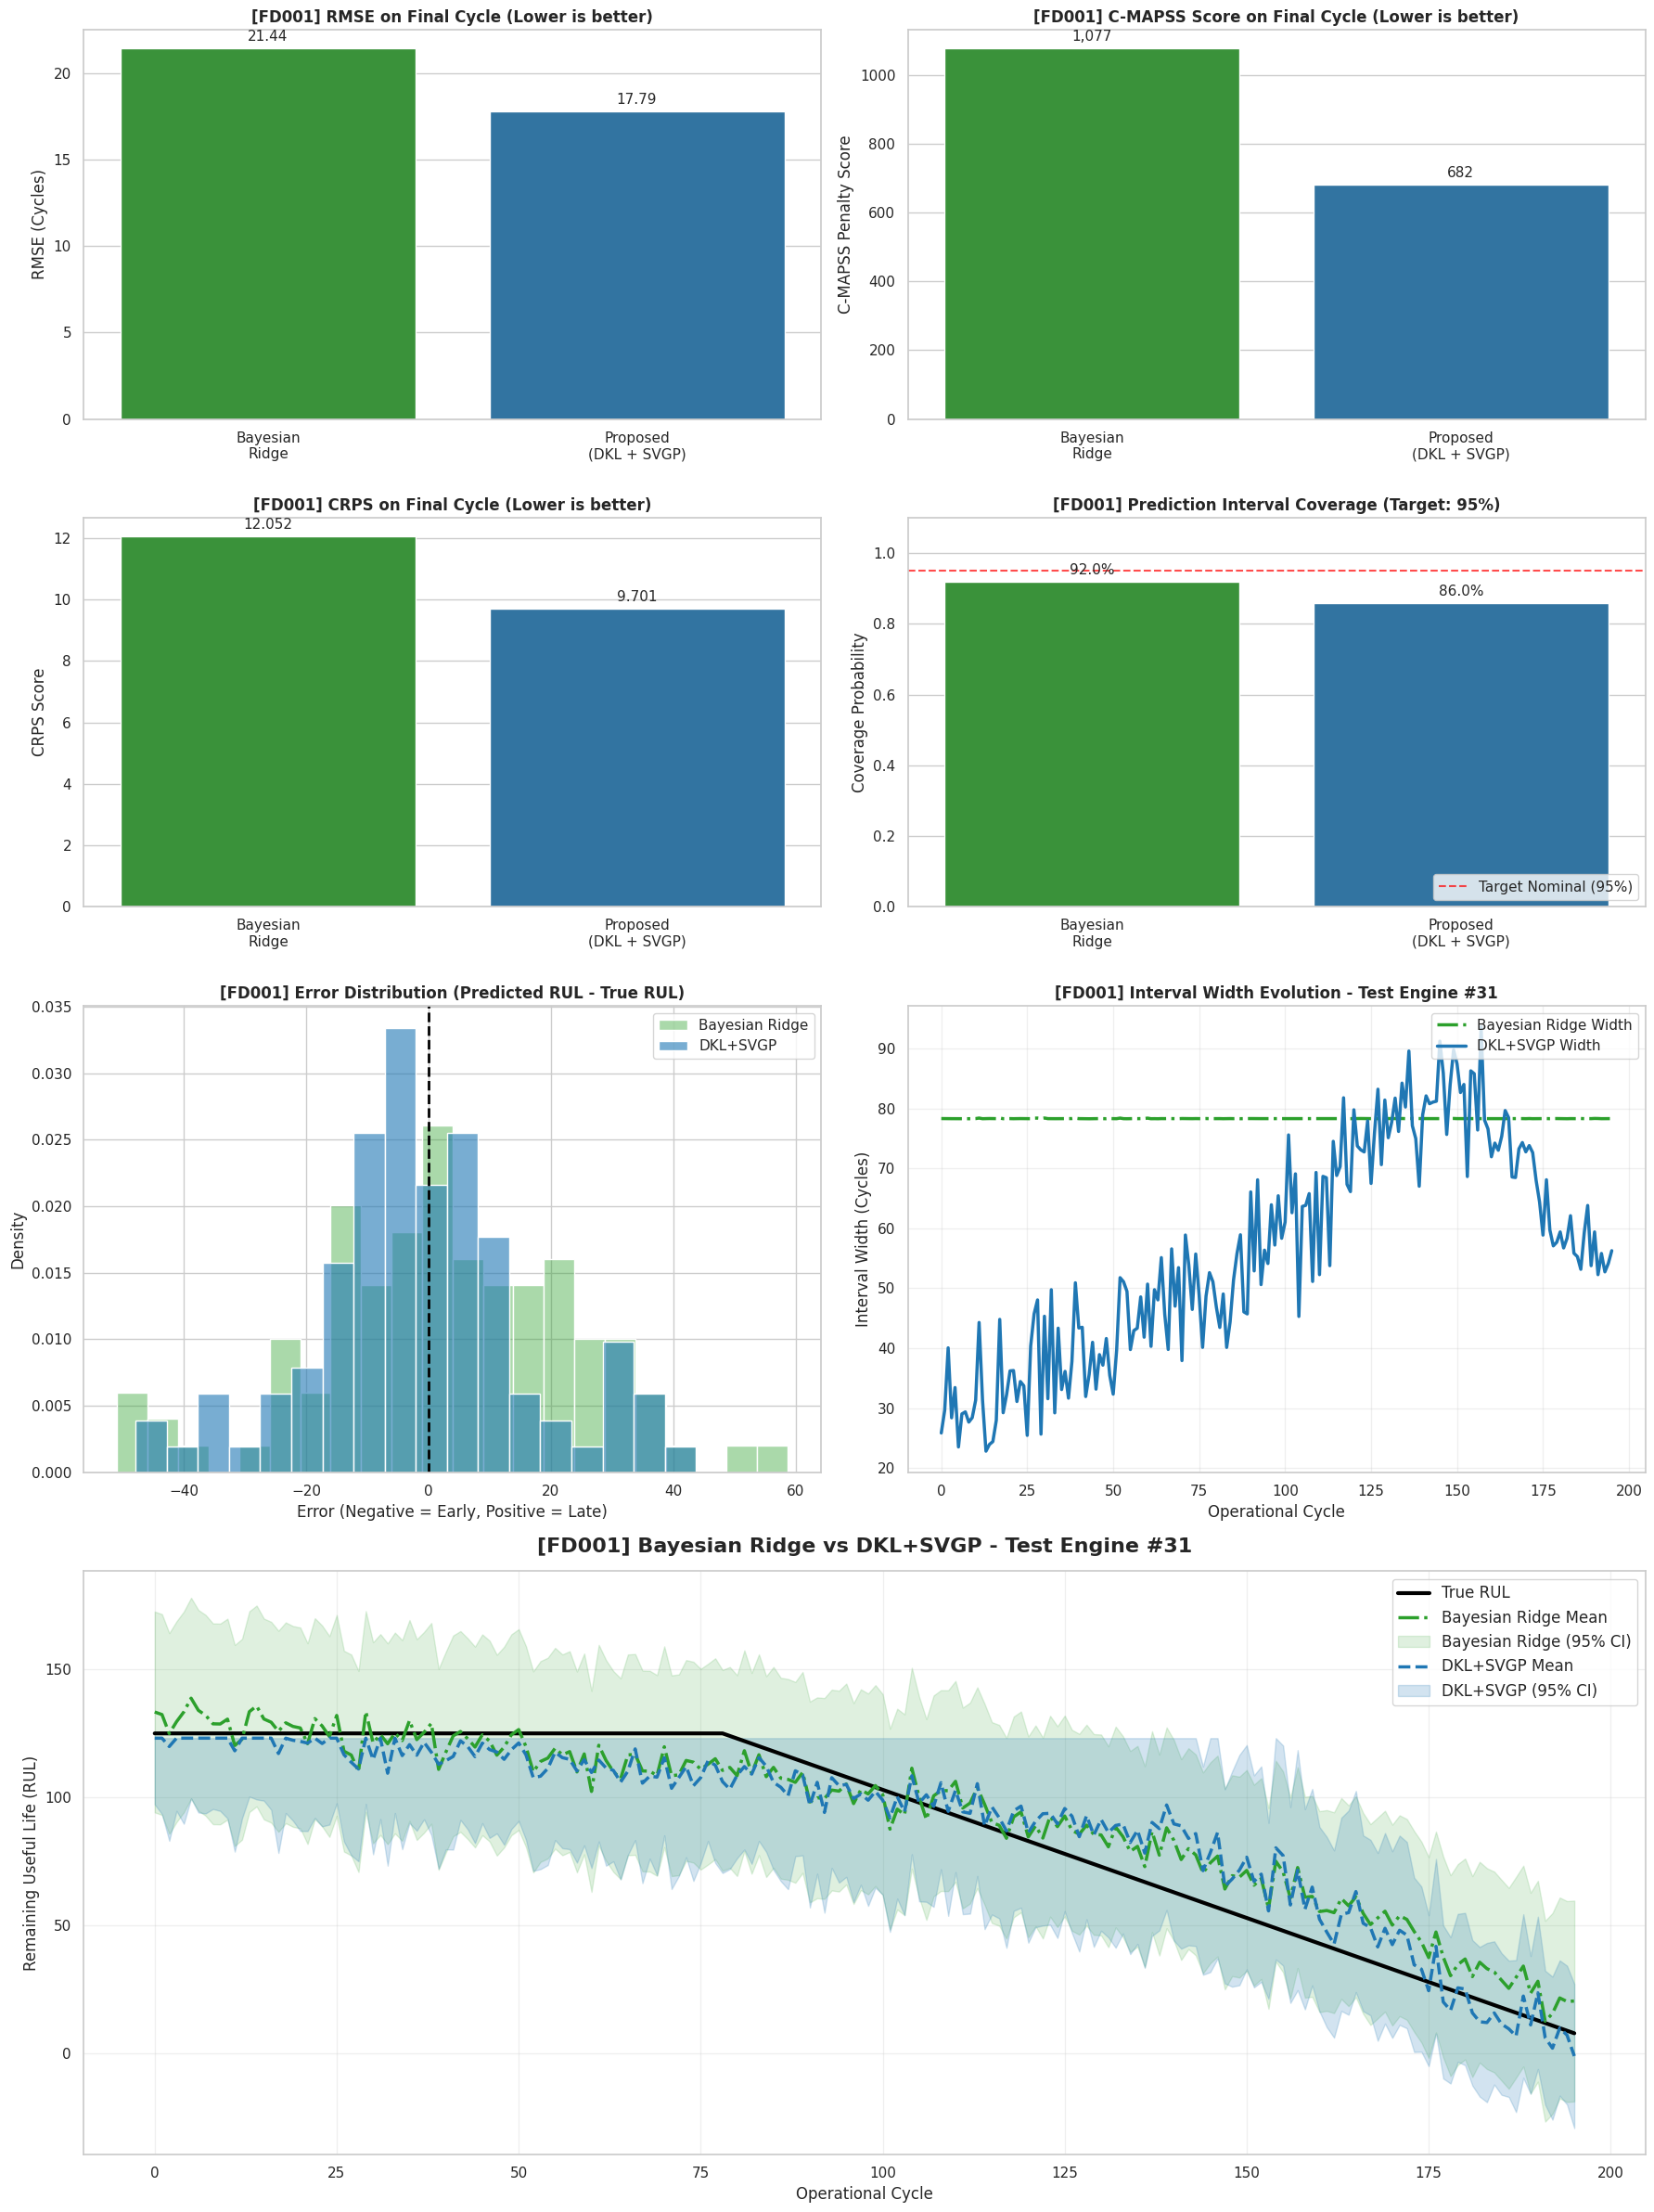

In [5]:
import importlib
import src.models.train_dkl_svgp
importlib.reload(src.models.train_dkl_svgp)
from src.models.train_dkl_svgp import train_dkl_autoencoder


br_dkl_results = {}

# Test FD001
br_dkl_results['FD001'] = compare_br_vs_dkl_dataset('FD001', dkl_epochs=30)



🔬 INIZIO VALUTAZIONE PROBABILISTICA COMPLETA: BR vs DKL+SVGP [FD002]
🌍 Dataset multi-regime rilevato: Applicazione RegimeConditionedScaler (6 cluster)...
Training Baseline (Bayesian Ridge) con feature temporale integrata...
Bayesian Ridge salvata in br_model_FD002.pkl
Training Proposed Model (DKL+SVGP - 30 epoche)...
--- Encoder Warm-up (10 epochs, reconstruction only) ---
  Warm-up epoch 01 | Recon Loss: 0.2212
  Warm-up epoch 02 | Recon Loss: 0.0499
  Warm-up epoch 03 | Recon Loss: 0.0317
  Warm-up epoch 04 | Recon Loss: 0.0248
  Warm-up epoch 05 | Recon Loss: 0.0207
  Warm-up epoch 06 | Recon Loss: 0.0171
  Warm-up epoch 07 | Recon Loss: 0.0147
  Warm-up epoch 08 | Recon Loss: 0.0132
  Warm-up epoch 09 | Recon Loss: 0.0123
  Warm-up epoch 10 | Recon Loss: 0.0119
RUL scale derivato dal dataset: 41.6652
Likelihood noise auto-calibrato: 0.0576  (=10.0 cicli std in spazio fisico)
--- Starting DKL Autoencoder SVGP Training (30 Epochs) ---
Epoch 01 | ELBO: 2.9243 | Recon: 0.0150 | Asymm

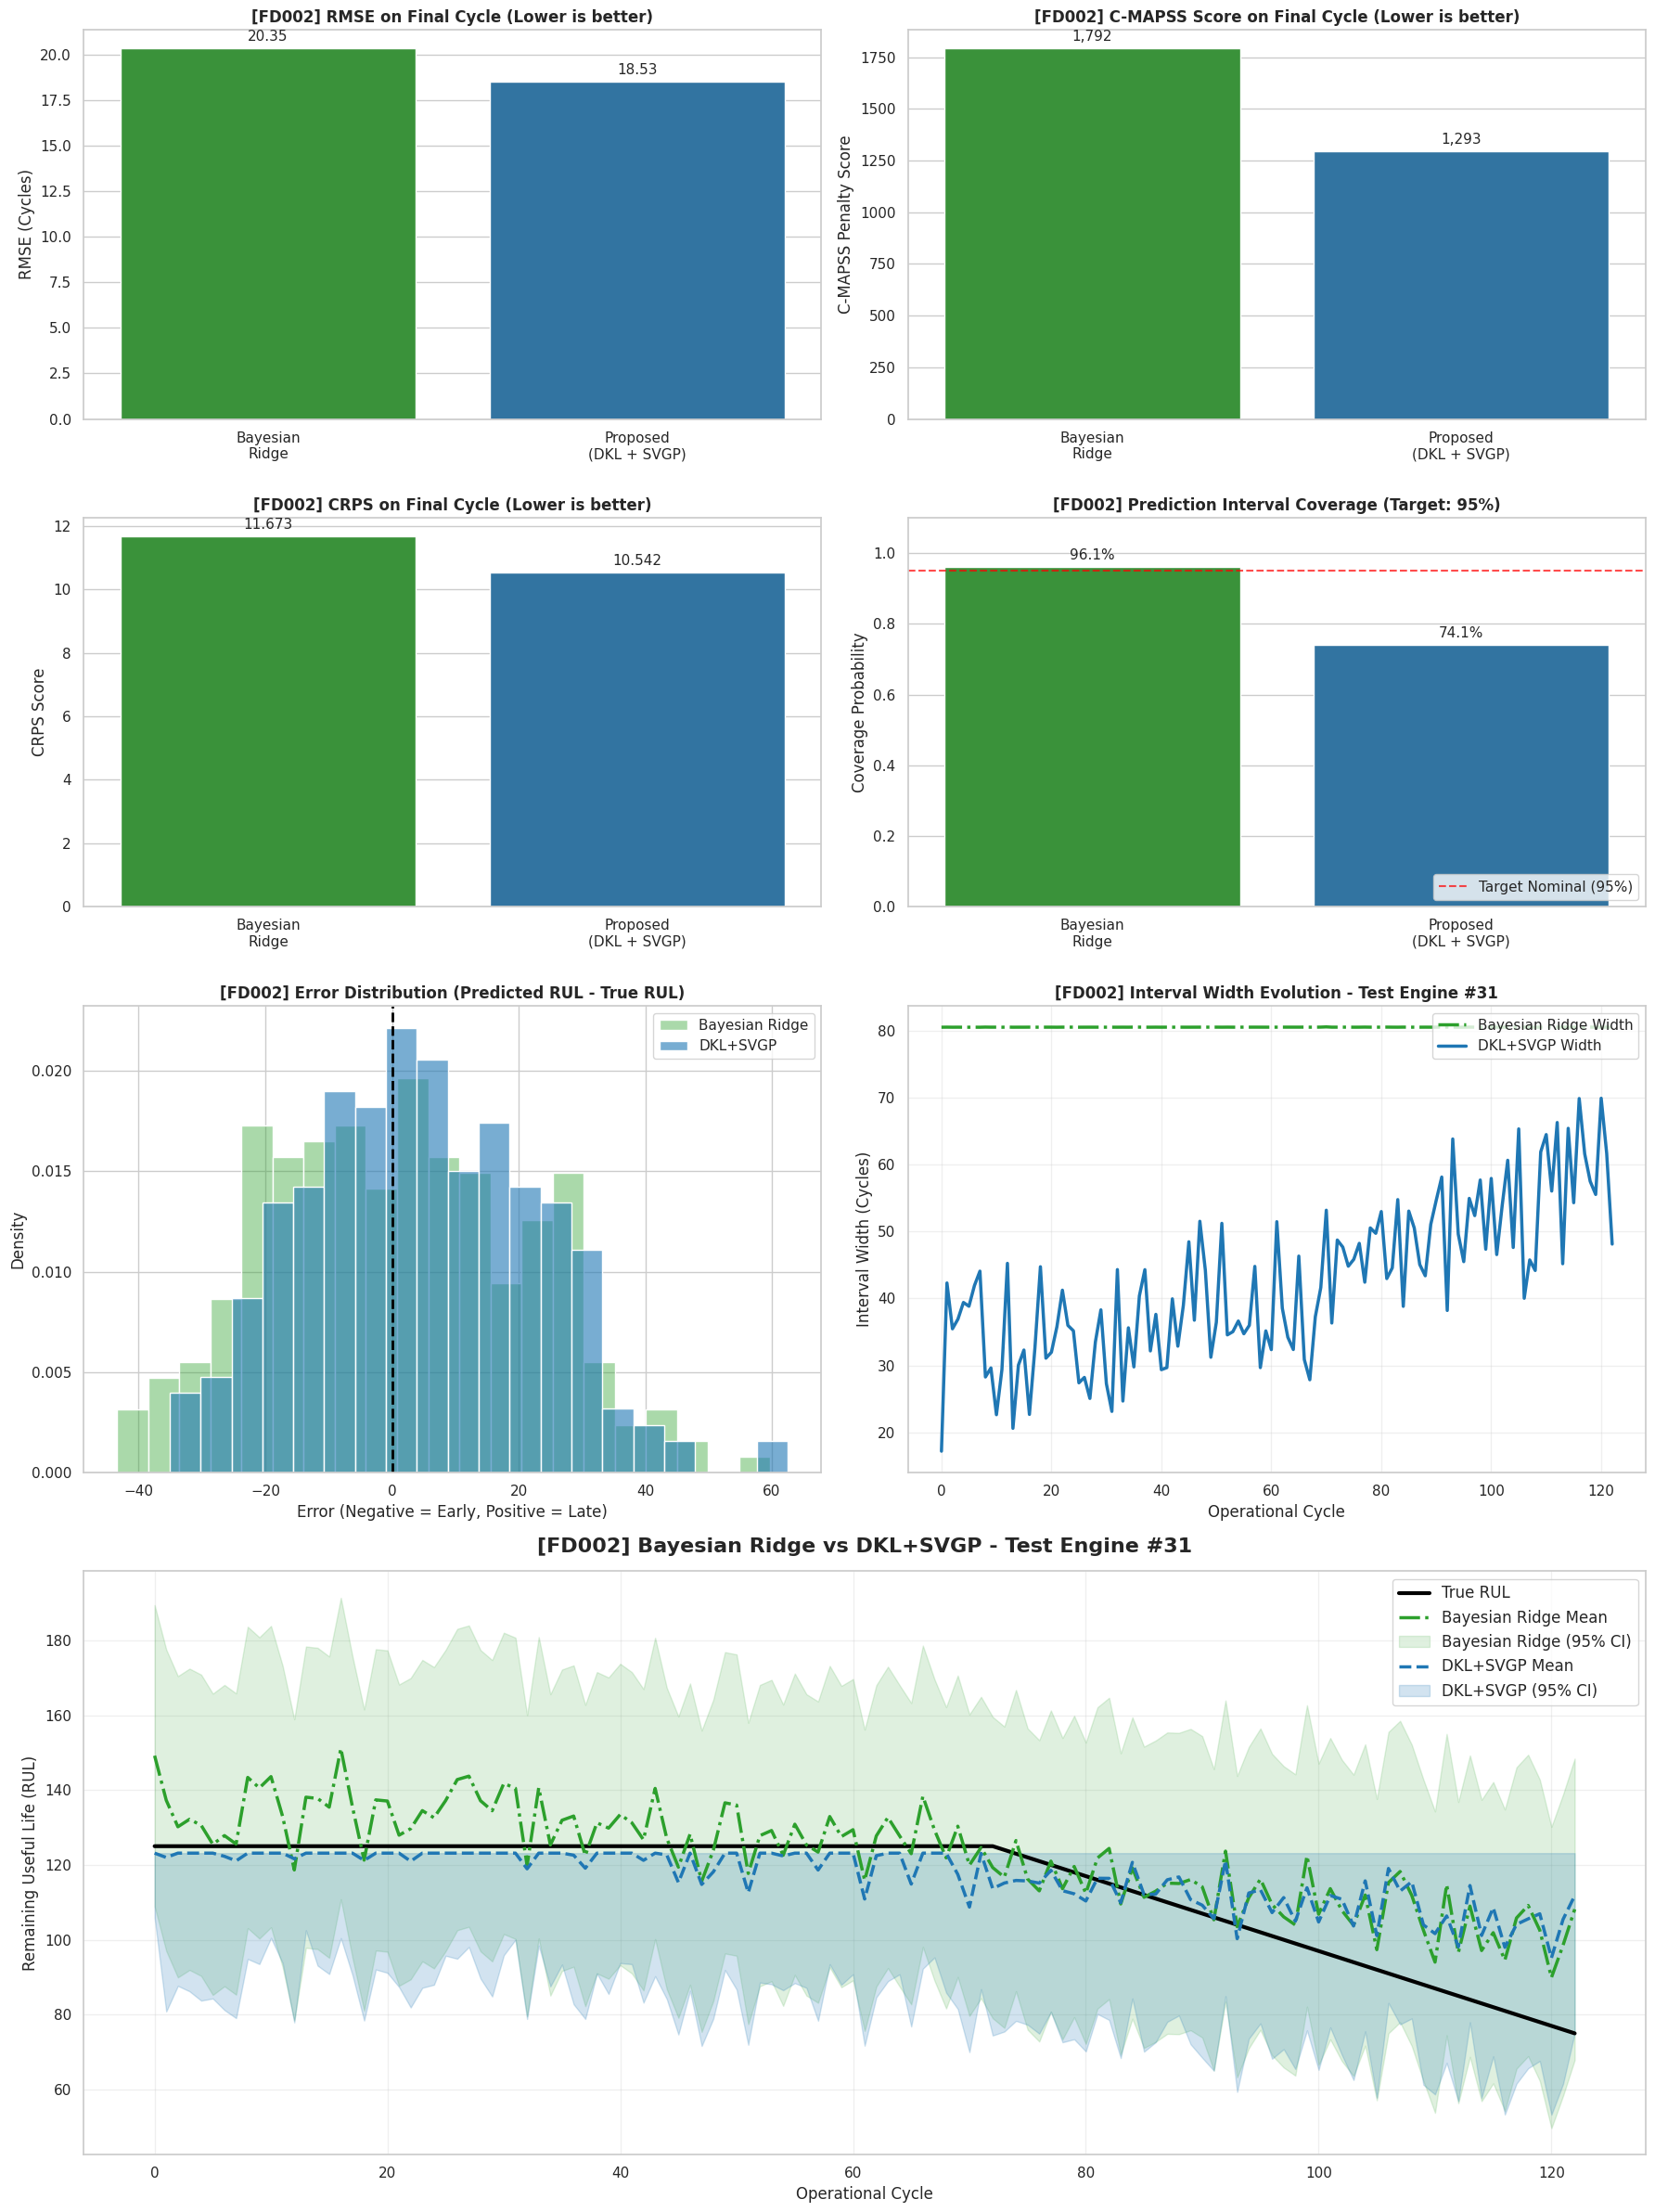

In [6]:
import importlib
import src.models.train_dkl_svgp
importlib.reload(src.models.train_dkl_svgp)
from src.models.train_dkl_svgp import train_dkl_autoencoder

# Test FD002
br_dkl_results['FD002'] = compare_br_vs_dkl_dataset('FD002', dkl_epochs=30)

In [7]:
import src.models.train_dkl_svgp as m
import inspect
print(inspect.getfile(m))

import importlib
import src.models.train_dkl_svgp as m
importlib.reload(m)
print(f"Noise dopo reload: cerca 'GaussianLikelihood' nel file")

/home/emma/ProbML/PML_Final_Project/src/models/train_dkl_svgp.py
Noise dopo reload: cerca 'GaussianLikelihood' nel file




🔬 INIZIO VALUTAZIONE PROBABILISTICA COMPLETA: BR vs DKL+SVGP [FD003]
✈️ Dataset mono-regime rilevato: Applicazione StandardScaler globale...
Training Baseline (Bayesian Ridge) con feature temporale integrata...
Bayesian Ridge salvata in br_model_FD003.pkl
Training Proposed Model (DKL+SVGP - 30 epoche)...
--- Encoder Warm-up (10 epochs, reconstruction only) ---
  Warm-up epoch 01 | Recon Loss: 0.3040
  Warm-up epoch 02 | Recon Loss: 0.0773
  Warm-up epoch 03 | Recon Loss: 0.0423
  Warm-up epoch 04 | Recon Loss: 0.0288
  Warm-up epoch 05 | Recon Loss: 0.0203
  Warm-up epoch 06 | Recon Loss: 0.0156
  Warm-up epoch 07 | Recon Loss: 0.0127
  Warm-up epoch 08 | Recon Loss: 0.0109
  Warm-up epoch 09 | Recon Loss: 0.0097
  Warm-up epoch 10 | Recon Loss: 0.0088
RUL scale derivato dal dataset: 40.6263
Likelihood noise auto-calibrato: 0.0606  (=10.0 cicli std in spazio fisico)
--- Starting DKL Autoencoder SVGP Training (30 Epochs) ---
Epoch 01 | ELBO: 2.1502 | Recon: 0.0099 | Asymm: 11.4141 | I

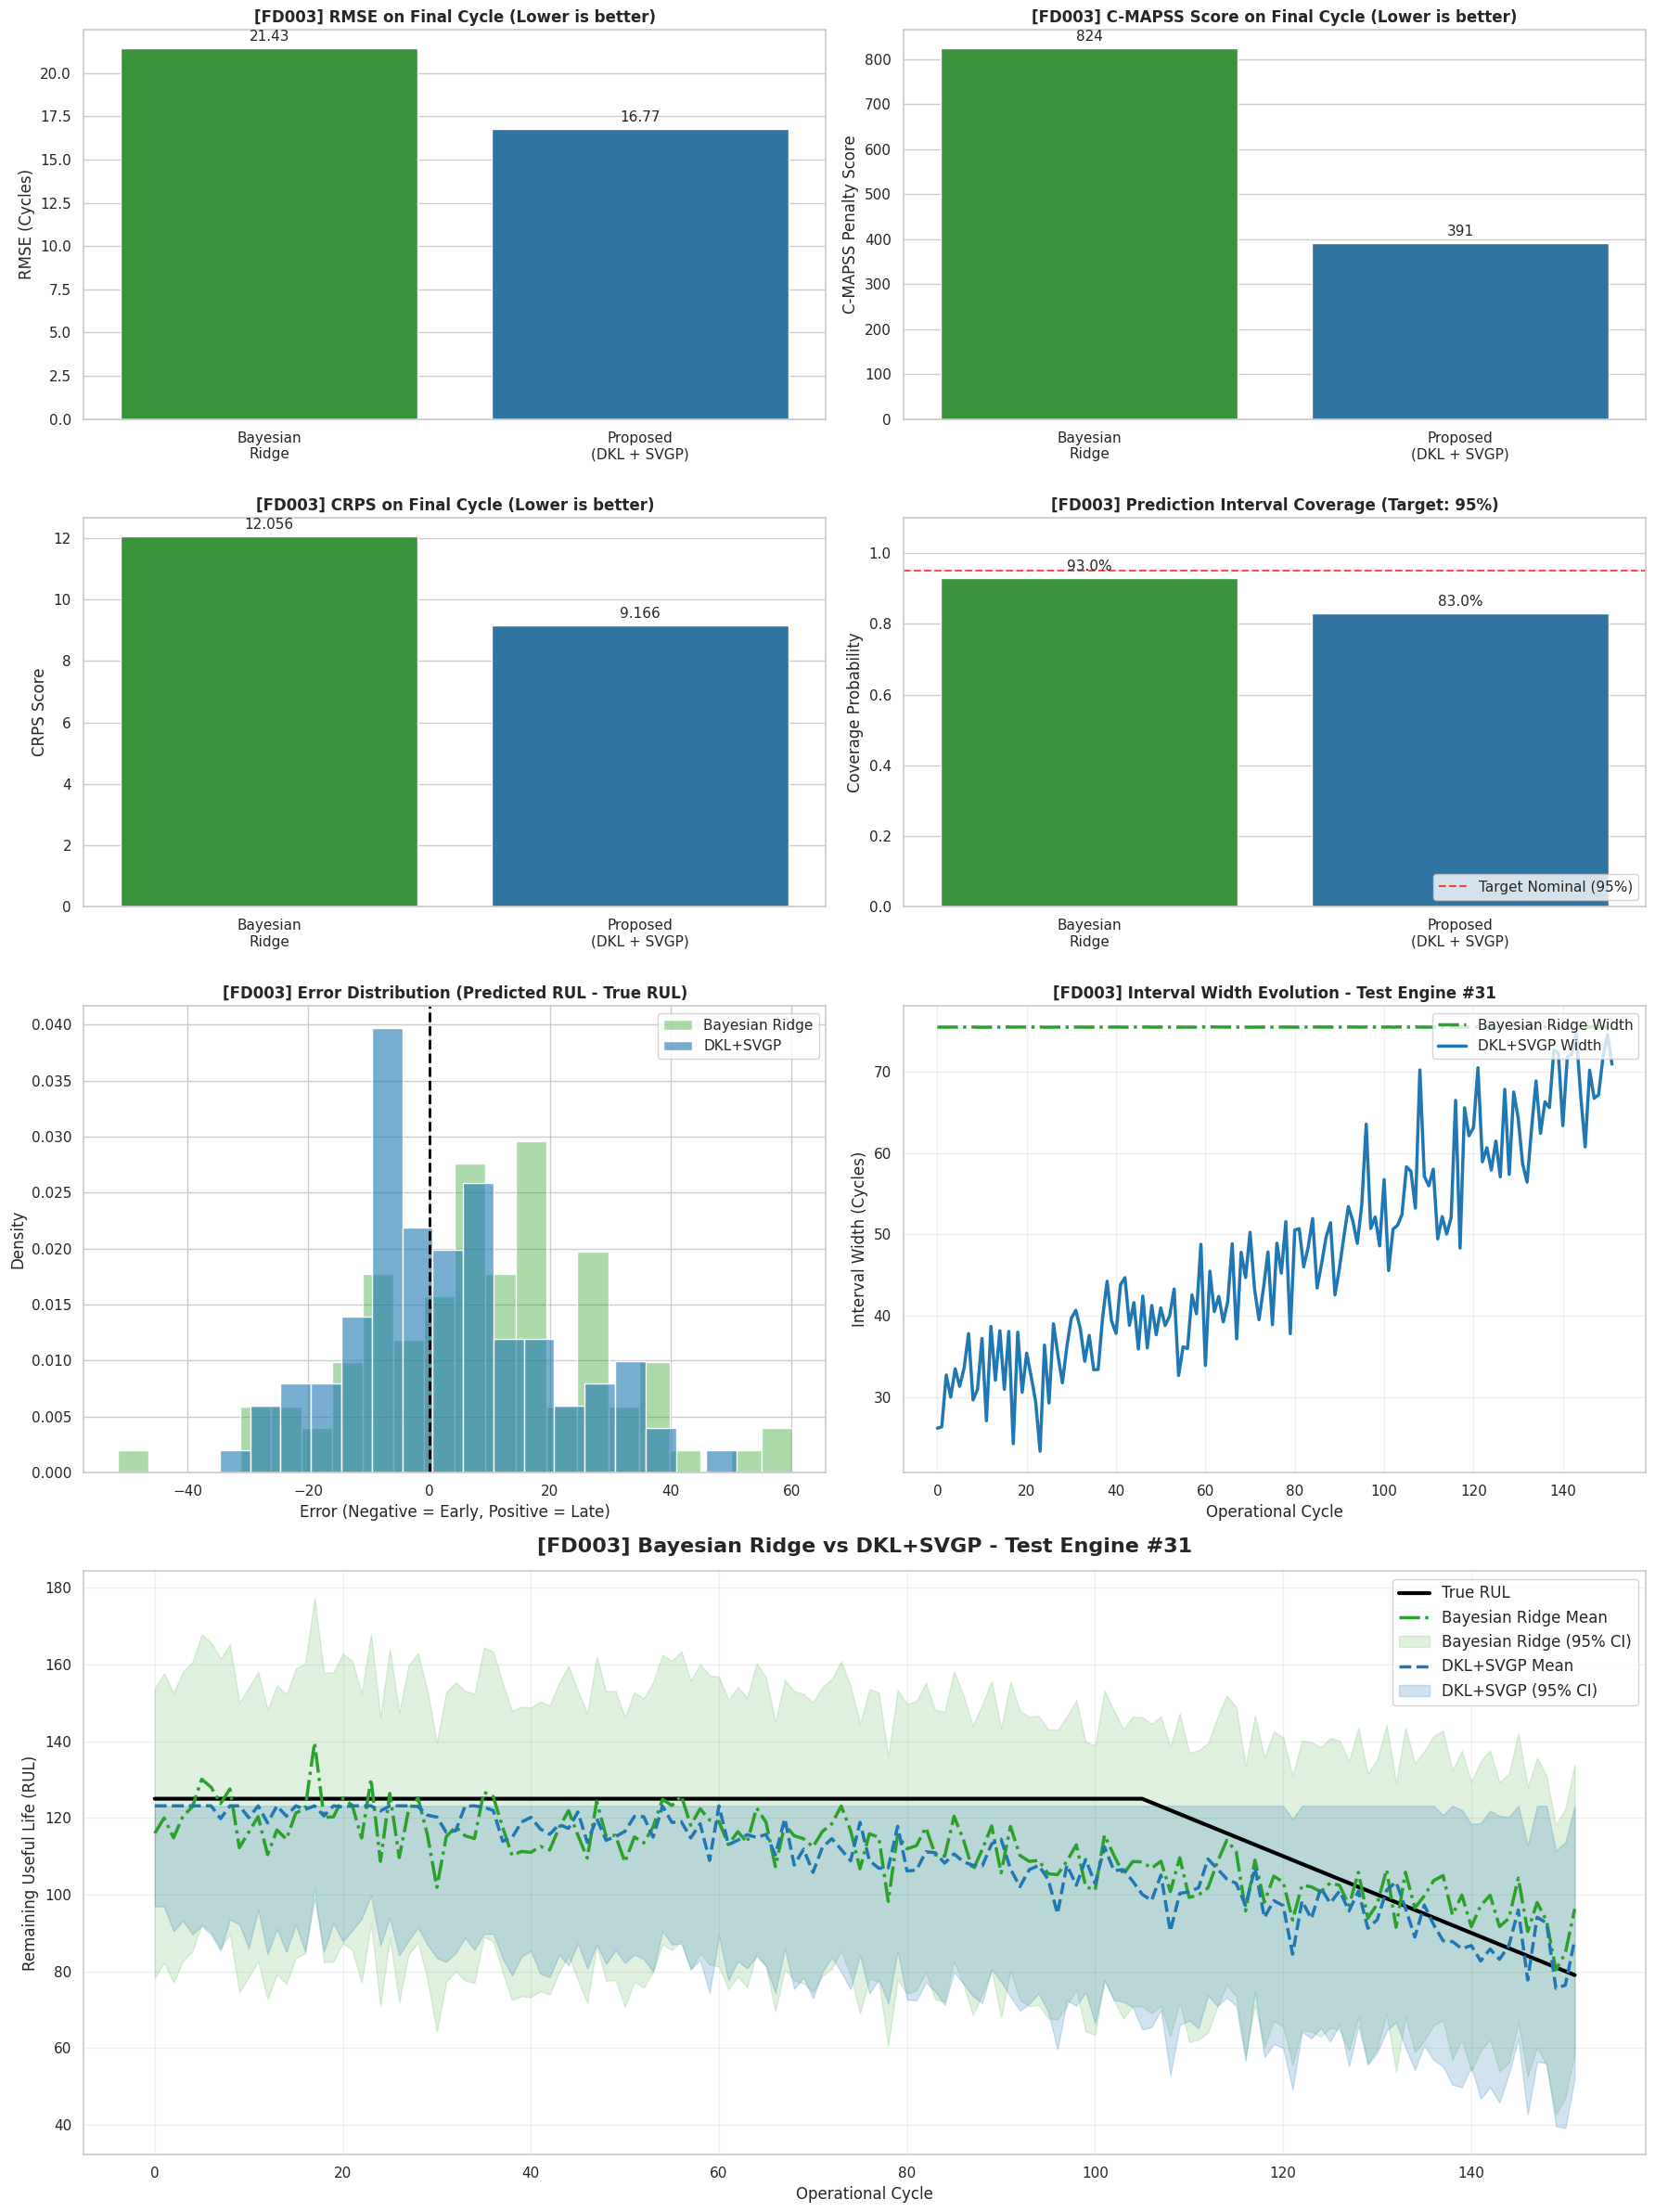

In [8]:
import importlib
import src.models.train_dkl_svgp
importlib.reload(src.models.train_dkl_svgp)
from src.models.train_dkl_svgp import train_dkl_autoencoder

# Test FD003
br_dkl_results['FD003'] = compare_br_vs_dkl_dataset('FD003', dkl_epochs=30)



🔬 INIZIO VALUTAZIONE PROBABILISTICA COMPLETA: BR vs DKL+SVGP [FD004]
🌍 Dataset multi-regime rilevato: Applicazione RegimeConditionedScaler (6 cluster)...
Training Baseline (Bayesian Ridge) con feature temporale integrata...
Bayesian Ridge salvata in br_model_FD004.pkl
Training Proposed Model (DKL+SVGP - 30 epoche)...
--- Encoder Warm-up (10 epochs, reconstruction only) ---
  Warm-up epoch 01 | Recon Loss: 0.1706
  Warm-up epoch 02 | Recon Loss: 0.0367
  Warm-up epoch 03 | Recon Loss: 0.0204
  Warm-up epoch 04 | Recon Loss: 0.0178
  Warm-up epoch 05 | Recon Loss: 0.0158
  Warm-up epoch 06 | Recon Loss: 0.0146
  Warm-up epoch 07 | Recon Loss: 0.0137
  Warm-up epoch 08 | Recon Loss: 0.0131
  Warm-up epoch 09 | Recon Loss: 0.0124
  Warm-up epoch 10 | Recon Loss: 0.0118
RUL scale derivato dal dataset: 40.6648
Likelihood noise auto-calibrato: 0.0605  (=10.0 cicli std in spazio fisico)
--- Starting DKL Autoencoder SVGP Training (30 Epochs) ---
Epoch 01 | ELBO: 2.9423 | Recon: 0.0145 | Asymm

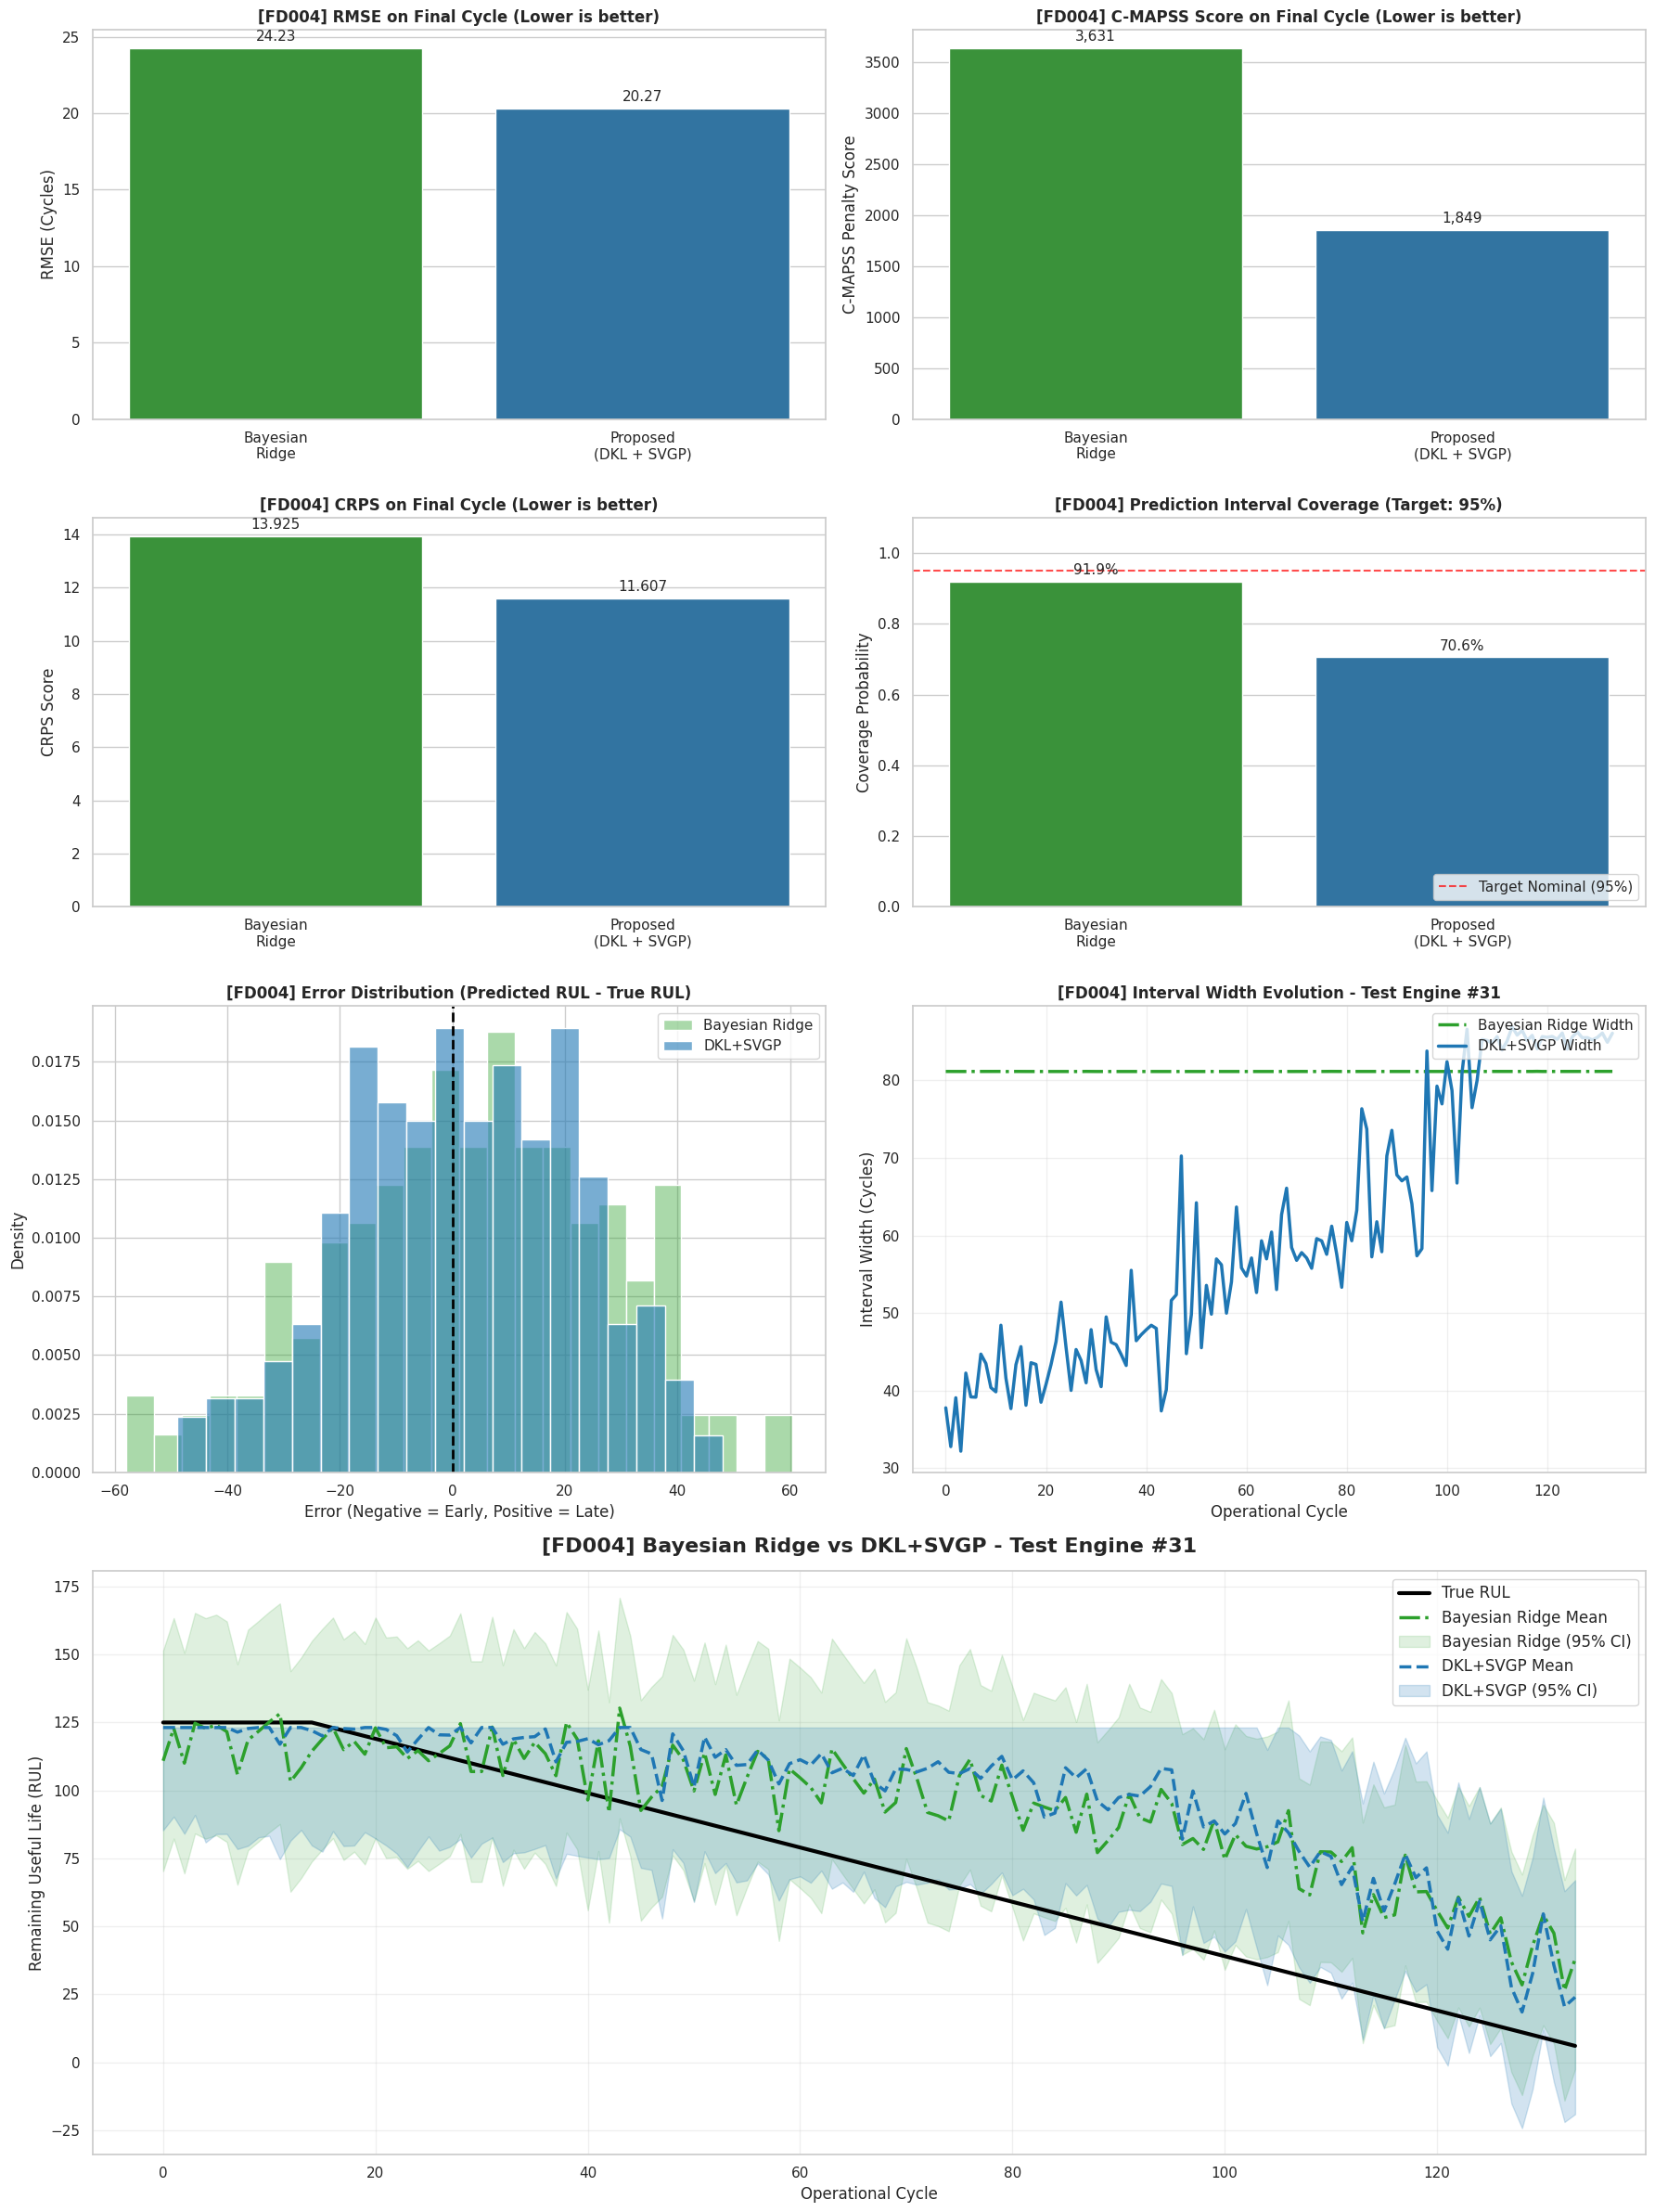


=== SUMMARY METRIC COMPARISON: BAYESIAN RIDGE vs DKL) ===
FD001 -> BR RMSE: 21.44 | DKL RMSE: 17.79
FD002 -> BR RMSE: 20.35 | DKL RMSE: 18.53
FD003 -> BR RMSE: 21.43 | DKL RMSE: 16.77
FD004 -> BR RMSE: 24.23 | DKL RMSE: 20.27


In [9]:
# Test FD004
br_dkl_results['FD004'] = compare_br_vs_dkl_dataset('FD004', dkl_epochs=30)

print("\n=== SUMMARY METRIC COMPARISON: BAYESIAN RIDGE vs DKL) ===")
for ds, metrics in br_dkl_results.items():
    print(f"{ds} -> BR RMSE: {metrics['br_rmse']:.2f} | DKL RMSE: {metrics['dkl_rmse']:.2f}")

In [10]:
'''
# ==============================================================================
# COMPARE: BAYESIAN RIDGE vs DKL + SVGP (WITH ONLINE LEARNING)
# ==============================================================================
import os
import sys
from pathlib import Path

import joblib
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import DataLoader
import gpytorch


PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

from src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset
from src.utils.metrics import (
    evaluate_prognostics_model,
    gaussian_nll_from_mean_var,
    crps_gaussian
)
from src.models.train_dkl_svgp import train_dkl_autoencoder
from src.models.online_updater import simulate_online_stream_and_update  # <-- AGGIUNTO

# Assicurati che PROJECT_ROOT e DATA_DIR siano definiti prima di chiamare questa funzione

CHECKPOINTS_DIR = PROJECT_ROOT / 'artifacts' / 'checkpoints'
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def compare_br_vs_dkl_dataset(
    dataset_name, 
    dkl_epochs=50, 
    use_saved_model=True, 
    online_fine_tune_epochs=1,     # <-- NUOVO: epoche di aggiornamento online
    update_every_x_cycles=10       # <-- NUOVO: frequenza di aggiornamento
):
    print(f"\n\n{'='*90}")
    print(f"🔬 INIZIO VALUTAZIONE PROBABILISTICA (ONLINE LEARNING): BR vs DKL+SVGP [{dataset_name}]")
    print(f"{'='*90}")

    br_model_path = CHECKPOINTS_DIR / f'br_model_{dataset_name}.pkl'
    dkl_model_path = CHECKPOINTS_DIR / f'dkl_model_{dataset_name}.pth'
    likelihood_path = CHECKPOINTS_DIR / f'likelihood_{dataset_name}.pth'

    # 1. Load data
    df_train = load_cmapss_data(str(DATA_DIR / f'train_{dataset_name}.txt'), max_rul=125, smooth_targets=False)
    df_test = load_cmapss_data(str(DATA_DIR / f'test_{dataset_name}.txt'), str(DATA_DIR / f'RUL_{dataset_name}.txt'), max_rul=125, smooth_targets=False)

    # 2. Feature Selection (Settings + Sensors)
    candidate_cols = ['setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    variances = df_train[candidate_cols].var()
    dead_cols = variances[variances == 0].index.tolist()
    features = [c for c in candidate_cols if c not in dead_cols]

    # 3. Inizializzazione Scaler
    feature_scaler = StandardScaler()
    time_scaler = MinMaxScaler()

    # Creazione del Dataset di Train
    train_dataset = StreamingCMAPSSDataset(
        df=df_train,
        features=features,
        scaler=feature_scaler,
        fit_scaler=True,
        time_scaler=time_scaler,
        fit_time_scaler=True,
        fit_target_transform=True,
        max_rul=125.0
    )
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)

    # Creazione Dataset di Test
    test_dataset = StreamingCMAPSSDataset(
        df=df_test,
        features=features,
        scaler=feature_scaler,
        fit_scaler=False,
        time_scaler=time_scaler,
        fit_time_scaler=False,
        target_transform=train_dataset.target_transform,
        fit_target_transform=False,
        max_rul=125.0
    )

    # Dataloader specifico per l'online learning (batch_size=1)
    test_loader_stream = DataLoader(test_dataset, batch_size=1, shuffle=False)

    # Estrazione tensori scalati per Baseline
    X_train_scaled = train_dataset.X.numpy()
    y_train = train_dataset.y_raw.numpy().flatten()
    X_test_scaled = test_dataset.X.numpy()
    y_test_true = test_dataset.y_raw.numpy().flatten()

    # 5. Extracting Last Cycles (Per le metriche CMAPSS ufficiali puntuali)
    last_cycle_indices = df_test.groupby('unit_nr').tail(1).index
    X_test_last = X_test_scaled[last_cycle_indices]
    y_test_last = y_test_true[last_cycle_indices]
    unit_nrs_last = df_test.iloc[last_cycle_indices]['unit_nr'].values

    # ==========================================
    # --- BAYESIAN RIDGE (STATIC BASELINE) ---
    # ==========================================
    if use_saved_model and br_model_path.exists():
        print(f"Loading Baseline (Bayesian Ridge) from disk for {dataset_name}...")
        br_model = joblib.load(br_model_path)
    else:
        print("Training Baseline (Bayesian Ridge)...")
        br_model = BayesianRidge()
        br_model.fit(X_train_scaled, y_train)
        joblib.dump(br_model, br_model_path)
        print(f"Bayesian Ridge salvata in {br_model_path.name}")

    # Probabilistic predictive params (last cycle)
    br_preds_last, br_std_last = br_model.predict(X_test_last, return_std=True)
    br_var_last = br_std_last ** 2
    br_lower_last = br_preds_last - (1.96 * br_std_last)
    br_upper_last = br_preds_last + (1.96 * br_std_last)
    
    # Metrics evaluation (Baseline)
    br_metrics = evaluate_prognostics_model(
        br_preds_last, y_test_last, 
        predictive_vars=br_var_last, lower_bounds=br_lower_last, upper_bounds=br_upper_last
    )
    br_nll = gaussian_nll_from_mean_var(br_preds_last, br_var_last, y_test_last)
    br_crps = crps_gaussian(br_preds_last, br_var_last, y_test_last)

    # Trajectory predictions (all cycles for Baseline)
    br_preds_all, br_std_all = br_model.predict(X_test_scaled, return_std=True)
    br_lower_all = br_preds_all - (1.96 * br_std_all)
    br_upper_all = br_preds_all + (1.96 * br_std_all)

    # ==========================================
    # --- DKL + SVGP (ONLINE LEARNING) ---
    # ==========================================
    if use_saved_model and dkl_model_path.exists() and likelihood_path.exists():
        print(f"🔄 Caricamento Modello Proposto (DKL+SVGP) da disco per {dataset_name}...")
        dkl_model = torch.load(dkl_model_path, weights_only=False, map_location=device)
        likelihood = torch.load(likelihood_path, weights_only=False, map_location=device)
    else:
        print(f"Training Proposed Model (DKL+SVGP - {dkl_epochs} epoche)...")
        dkl_model, likelihood = train_dkl_autoencoder(
            train_loader=train_loader, input_dim=len(features), latent_dim=16,
            num_inducing=500, epochs=dkl_epochs, encoder_lr=1e-4,
            decoder_lr=1e-4, gp_lr=5e-4, lambda_recon=0.5,
            lambda_asymm=0.5, lambda_interval=1.0,
            interval_alpha=0.05, interval_alpha_lo_scale=0.2,
            beta_kl=0.5, grad_clip=1.0, seed=42
        )
        torch.save(dkl_model, dkl_model_path)
        torch.save(likelihood, likelihood_path)
        print(f"Modello DKL+SVGP salvato in {dkl_model_path.name}")

    print(f"\n🔄 Esecuzione Online Learning Streaming per DKL+SVGP sul set di Test...")
    print(f"Adattamento effettuato ogni {update_every_x_cycles} cicli per {online_fine_tune_epochs} epoche.")
    
    # AL POSTO DELLA PREDIZIONE STATICA, SIMULIAMO L'ONLINE LEARNING
    dkl_stream_results = simulate_online_stream_and_update(
        model=dkl_model,
        likelihood=likelihood,
        stream_loader=test_loader_stream,
        update_every_x_cycles=update_every_x_cycles,
        fine_tune_epochs=online_fine_tune_epochs,
        lr=0.001,
        lambda_recon=0.0,
        collect_metrics=True,
        device=str(device)
    )

    # Estraiamo le predizioni di tutto lo stream (già invertite/scalate in cicli fisici dalla funzione)
    dkl_preds_all = np.array(dkl_stream_results['predictions']['y_pred'])
    dkl_var_all = np.array(dkl_stream_results['predictions']['y_var'])
    dkl_lower_all = np.array(dkl_stream_results['predictions']['lower_95'])
    dkl_upper_all = np.array(dkl_stream_results['predictions']['upper_95'])

    # Estrazione per il calcolo delle metriche limitatamente agli "ultimi cicli" per uniformità di confronto
    dkl_preds_last = dkl_preds_all[last_cycle_indices]
    dkl_var_last = dkl_var_all[last_cycle_indices]
    dkl_lower_last = dkl_lower_all[last_cycle_indices]
    dkl_upper_last = dkl_upper_all[last_cycle_indices]

    # Metrics evaluation (DKL)
    dkl_metrics = evaluate_prognostics_model(
        dkl_preds_last, y_test_last, 
        predictive_vars=dkl_var_last, lower_bounds=dkl_lower_last, upper_bounds=dkl_upper_last
    )
    dkl_nll = gaussian_nll_from_mean_var(dkl_preds_last, dkl_var_last, y_test_last)
    dkl_crps = crps_gaussian(dkl_preds_last, dkl_var_last, y_test_last)

    # ==========================================
    # --- REPORTING E PLOTTING ---
    # ==========================================
    print("\n --- STIME PUNTUALI E INTERVALLI DI CONFIDENZA (95%) SUI CICLI FINALI (Prime 5 UUT) ---")
    header = f"{'Unit ID':<8} | {'True RUL':<8} | {'BR Pred':<8} | {'Intervallo Bayesian Ridge':<32} | {'DKL Pred':<8} | {'Intervallo DKL+SVGP':<32}"
    print(header)
    print("-" * len(header))
    for i in range(min(5, len(unit_nrs_last))):
        br_width = br_upper_last[i] - br_lower_last[i]
        dkl_width = dkl_upper_last[i] - dkl_lower_last[i]
        
        br_str = f"[{br_lower_last[i]:.1f}, {br_upper_last[i]:.1f}] (w:{br_width:.1f})"
        dkl_str = f"[{dkl_lower_last[i]:.1f}, {dkl_upper_last[i]:.1f}] (w:{dkl_width:.1f})"
        
        print(f"UUT #{unit_nrs_last[i]:<4} | {y_test_last[i]:<8.0f} | {br_preds_last[i]:<8.1f} | {br_str:<32} | {dkl_preds_last[i]:<8.1f} | {dkl_str:<32}")
    print("-" * len(header))

    br_rmse = br_metrics['RMSE (Root Mean Squared Error)']
    dkl_rmse = dkl_metrics['RMSE (Root Mean Squared Error)']
    br_score_val = br_metrics['PHM08 Asymmetric Score (Lower is better)']
    dkl_score_val = dkl_metrics['PHM08 Asymmetric Score (Lower is better)']

    print("\n --- REPORT METRICHE FINALI COMPLETO ---")
    print(f"{'Metrica':<45} | {'Bayesian Ridge':<15} | {'DKL+SVGP (Online)':<15}")
    print("-" * 81)
    print(f"{'RMSE (Cicli) [↓]':<45} | {br_rmse:<15.2f} | {dkl_rmse:<15.2f}")
    print(f"{'MAE (Cicli) [↓]':<45} | {br_metrics['MAE (Mean Absolute Error)']:<15.2f} | {dkl_metrics['MAE (Mean Absolute Error)']:<15.2f}")
    print(f"{'R-Squared (R2) [↑]':<45} | {br_metrics['R2 (Higher is better)']:<15.3f} | {dkl_metrics['R2 (Higher is better)']:<15.3f}")
    print(f"{'C-MAPSS Score [↓]':<45} | {br_score_val:<15.0f} | {dkl_score_val:<15.0f}")
    print(f"{'Fleet Correlation Metric [↑]':<45} | {br_metrics['Fleet Correlation Metric (Higher is better)']:<15.3f} | {dkl_metrics['Fleet Correlation Metric (Higher is better)']:<15.3f}")
    print(f"{'Perfect Predictions (d = 0)':<45} | {br_metrics['Perfect Predictions (d = 0)']:<15} | {dkl_metrics['Perfect Predictions (d = 0)']:<15}")
    print(f"{'Early Predictions (d < 0, Sicuri)':<45} | {br_metrics['Early Predictions (d < 0, Safer)']:<15} | {dkl_metrics['Early Predictions (d < 0, Safer)']:<15}")
    print(f"{'Late Predictions (d > 0, Pericolosi)':<45} | {br_metrics['Late Predictions (d > 0, Dangerous)']:<15} | {dkl_metrics['Late Predictions (d > 0, Dangerous)']:<15}")
    print("-" * 81)
    print(f"{'Negative Log-Likelihood (NLL) [↓]':<45} | {br_nll:<15.3f} | {dkl_nll:<15.3f}")
    print(f"{'Continuous Ranked Prob. Score (CRPS) [↓]':<45} | {br_crps:<15.3f} | {dkl_crps:<15.3f}")
    print(f"{'PICP (Prediction Interval Coverage 95%)':<45} | {br_metrics.get('picp_95', 0)*100:<14.1f}% | {dkl_metrics.get('picp_95', 0)*100:<14.1f}%")
    print(f"{'Avg Prediction Interval Width [↓]':<45} | {br_metrics.get('avg_interval_width_95', 0):<15.2f} | {dkl_metrics.get('avg_interval_width_95', 0):<15.2f}")
    print(f"{'Avg Predictive Variance':<45} | {br_metrics.get('avg_pred_variance', 0):<15.2f} | {dkl_metrics.get('avg_pred_variance', 0):<15.2f}")
    print("-" * 81)

    # ==========================================================================
    # --- GRIGLIA DEI GRAFICI AVANZATI ---
    # ==========================================================================
    fig = plt.figure(figsize=(18, 18))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.5])

    ax_rmse = fig.add_subplot(gs[0, 0])
    ax_score = fig.add_subplot(gs[0, 1])
    ax_crps = fig.add_subplot(gs[1, 0])
    ax_picp = fig.add_subplot(gs[1, 1])
    ax_traj = fig.add_subplot(gs[2, :]) 

    models_labels = ['Bayesian\nRidge', 'Proposed\n(DKL + SVGP)']
    palette = ['#2ca02c', '#1f77b4'] 

    sns.barplot(x=models_labels, y=[br_rmse, dkl_rmse], ax=ax_rmse, hue=models_labels, palette=palette, legend=False)
    ax_rmse.set_title(f'[{dataset_name}] RMSE on Final Cycle (Lower is better)', fontsize=12, fontweight='bold')
    ax_rmse.set_ylabel('RMSE (Cycles)')
    for i, v in enumerate([br_rmse, dkl_rmse]):
        ax_rmse.text(i, v + (max(br_rmse, dkl_rmse)*0.02), f"{v:.2f}", ha='center', fontsize=11)

    sns.barplot(x=models_labels, y=[br_score_val, dkl_score_val], ax=ax_score, hue=models_labels, palette=palette, legend=False)
    ax_score.set_title(f'[{dataset_name}] C-MAPSS Score on Final Cycle (Lower is better)', fontsize=12, fontweight='bold')
    ax_score.set_ylabel('C-MAPSS Penalty Score')
    for i, v in enumerate([br_score_val, dkl_score_val]):
        ax_score.text(i, v + (max(br_score_val, dkl_score_val)*0.02), f"{v:,.0f}", ha='center', fontsize=11)

    sns.barplot(x=models_labels, y=[br_crps, dkl_crps], ax=ax_crps, hue=models_labels, palette=palette, legend=False)
    ax_crps.set_title(f'[{dataset_name}] CRPS on Final Cycle (Lower is better)', fontsize=12, fontweight='bold')
    ax_crps.set_ylabel('CRPS Score')
    for i, v in enumerate([br_crps, dkl_crps]):
        ax_crps.text(i, v + (max(br_crps, dkl_crps)*0.02), f"{v:.3f}", ha='center', fontsize=11)

    br_picp = br_metrics.get('picp_95', 0)
    dkl_picp = dkl_metrics.get('picp_95', 0)
    sns.barplot(x=models_labels, y=[br_picp, dkl_picp], ax=ax_picp, hue=models_labels, palette=palette, legend=False)
    ax_picp.axhline(0.95, color='red', linestyle='--', alpha=0.7, label='Target Nominal (95%)')
    ax_picp.set_title(f'[{dataset_name}] Prediction Interval Coverage (Target: 95%)', fontsize=12, fontweight='bold')
    ax_picp.set_ylabel('Coverage Probability')
    ax_picp.set_ylim(0, 1.1)
    ax_picp.legend(loc='lower right')
    for i, v in enumerate([br_picp, dkl_picp]):
        ax_picp.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontsize=11)

    first_engine_id = df_test['unit_nr'].unique()[0]
    eng_indices = df_test[df_test['unit_nr'] == first_engine_id].index
    y_true_eng = y_test_true[eng_indices]
    cycles = range(len(y_true_eng))

    ax_traj.plot(cycles, y_true_eng, label='True RUL', color='black', linewidth=3)
    
    ax_traj.plot(cycles, br_preds_all[eng_indices], label='Bayesian Ridge Mean (Static)', color='#2ca02c', linestyle='-.', linewidth=2.5)
    ax_traj.fill_between(cycles, br_lower_all[eng_indices], br_upper_all[eng_indices], color='#2ca02c', alpha=0.15, label='Bayesian Ridge (95% CI)')
    
    # La traiettoria DKL mostrerà l'adattamento online!
    ax_traj.plot(cycles, dkl_preds_all[eng_indices], label='DKL+SVGP Mean (Online Adaptive)', color='#1f77b4', linestyle='--', linewidth=2.5)
    ax_traj.fill_between(cycles, dkl_lower_all[eng_indices], dkl_upper_all[eng_indices], color='#1f77b4', alpha=0.2, label='DKL+SVGP (95% CI)')

    ax_traj.set_title(f'[{dataset_name}] Trajectory Evaluation - Test Engine #{first_engine_id}', fontsize=16, fontweight='bold', pad=15)
    ax_traj.set_xlabel('Operational Cycle', fontsize=12)
    ax_traj.set_ylabel('Remaining Useful Life (RUL)', fontsize=12)
    ax_traj.legend(fontsize=12, loc='upper right')
    ax_traj.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'br_rmse': br_rmse, 
        'dkl_rmse': dkl_rmse, 
        'br_score': br_score_val, 
        'dkl_score': dkl_score_val
    }
'''

'\n# ==============================================================================\n# COMPARE: BAYESIAN RIDGE vs DKL + SVGP (WITH ONLINE LEARNING)\n# ==============================================================================\nimport os\nimport sys\nfrom pathlib import Path\n\nimport joblib\nfrom sklearn.linear_model import BayesianRidge\nfrom sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score\nfrom sklearn.preprocessing import StandardScaler, MinMaxScaler\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nimport numpy as np\nimport torch\nfrom torch.utils.data import DataLoader\nimport gpytorch\n\n\nPROJECT_ROOT = Path.cwd().parent\nif str(PROJECT_ROOT) not in sys.path:\n    sys.path.append(str(PROJECT_ROOT))\n\nDATA_DIR = PROJECT_ROOT / \'data\' / \'raw\'\n\nfrom src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset\nfrom src.utils.metrics import (\n    evaluate_prognostics_model,\n    gaussian_nll_from_mean_var,\n    crps_gaussian\n)\nf

In [11]:
'''
results_online = {}

# Test FD002
results_online['FD002'] = compare_br_vs_dkl_dataset('FD002')
'''

"\nresults_online = {}\n\n# Test FD002\nresults_online['FD002'] = compare_br_vs_dkl_dataset('FD002')\n"